## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metrics.plots_metrics import *
from src.metrics.plots_metrics_comparison import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f'--> outputs logs in: {OUTPUT_PATH}')

--> outputs logs in: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs


## **UTILS**

### **CONFIG**

In [4]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [5]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [6]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [7]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [8]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [9]:
SCENARIO = 'optimistic'

BASE_CAR_BEHAVIOR = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

In [10]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

Scenario outputs folders in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic


In [11]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [12]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [13]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [14]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/50cars


##### *Initialisation*

In [15]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [16]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:27:52.519 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-30 16:27:52.566 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-30 16:27:52.632 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-30 16:27:52.689 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-30 16:27:52.694 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-30 16:27:52.785 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-30 16:27:52.871 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-30 16:27:52.919 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-30 16:27:52.973 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-30 16:27:53.024 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-30 16:27:53.084 | IN

##### *Metrics*

In [17]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 1.17 kWh
  Station 1: 0.00 kWh
  Station 2: 4.56 kWh
  Station 3: 15.59 kWh
  Station 4: 0.00 kWh
  Station 5: 55.08 kWh
  Station 6: 0.00 kWh
  Station 7: 2.83 kWh
  Station 8: 24.22 kWh
  Station 9: 1.83 kWh
  Station 10: 2.05 kWh
  Station 11: 0.00 kWh
  Station 12: 15.03 kWh
  Station 13: 26.11 kWh
  Station 14: 2.53 kWh
  Station 15: 1.20 kWh
  Station 16: 27.44 kWh
  Station 17: 12.44 kWh
  Station 18: 0.00 kWh
  Station 19: 0.00 kWh
  Station 20: 0.00 kWh
  Station 21: 2.29 kWh
  Station 22: 1.79 kWh
  Station 23: 6.93 kWh
  Station 24: 12.87 kWh
  Station 25: 5.17 kWh
  Station 26: 0.00 kWh
  Station 27: 0.00 kWh
  Station 28: 15.36 kWh
  Station 29: 10.69 kWh
  Station 30: 0.00 kWh
  Station 31: 1.80 kWh
  Station 32: 57.22 kWh
  Station 33: 85.73 kWh
  Station 34: 17.10 kWh
  Station 35: 15.44 kWh
  Station 36: 5.16 kWh
  Station 37: 5.26 kWh
  Station 38: 92.77 kWh
  Station 39: 22.73 kWh

--- User R

In [18]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

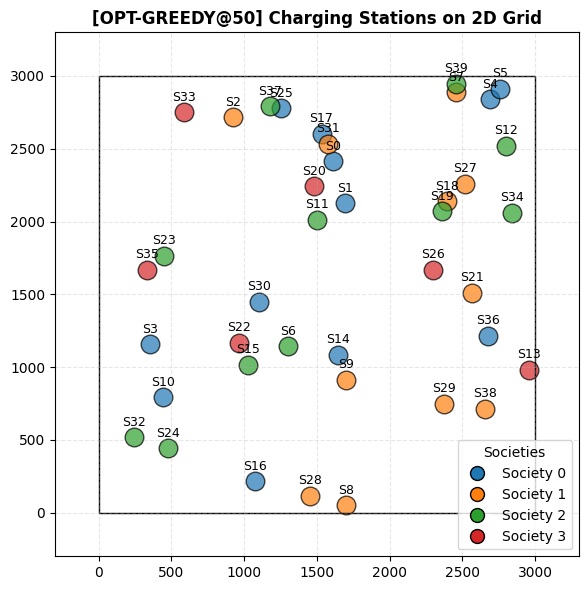

In [19]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

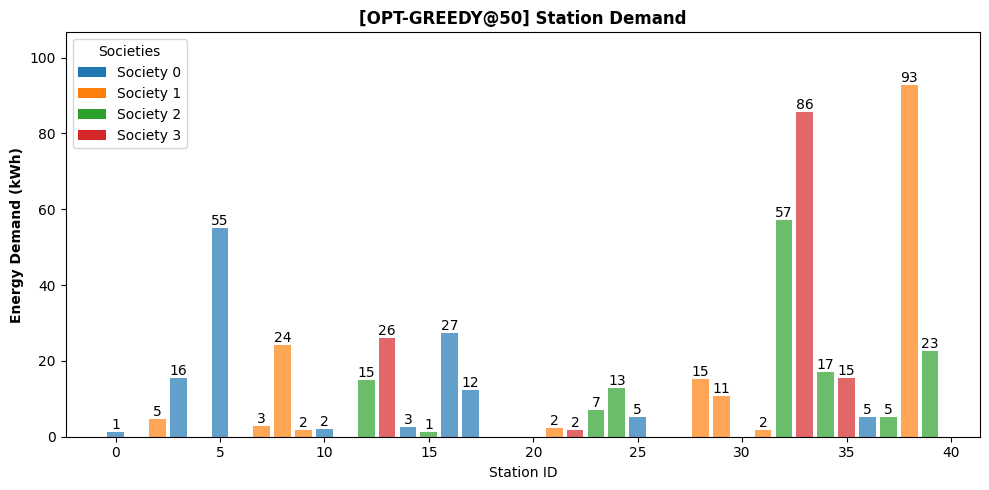

In [20]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

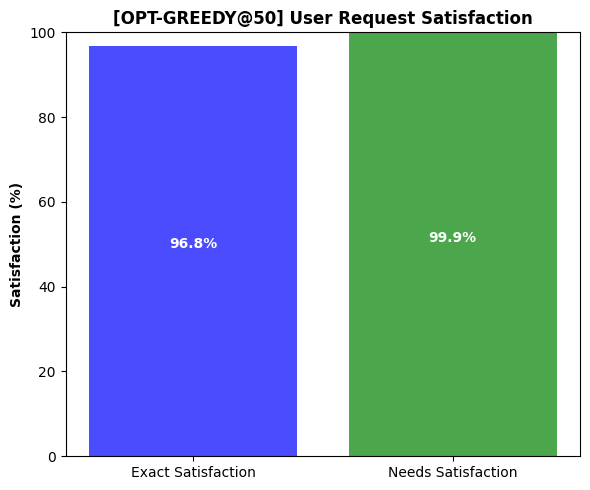

In [21]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

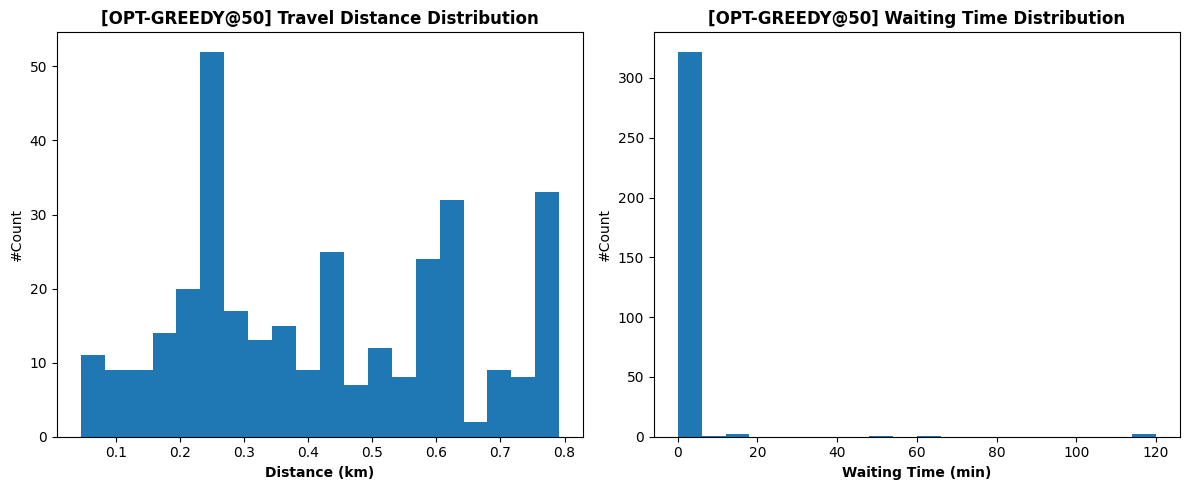

In [22]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

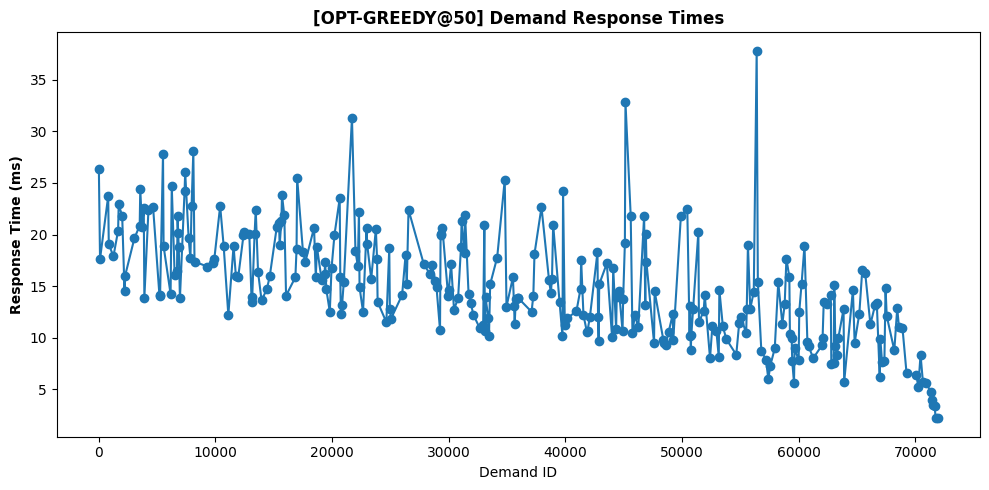

In [23]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

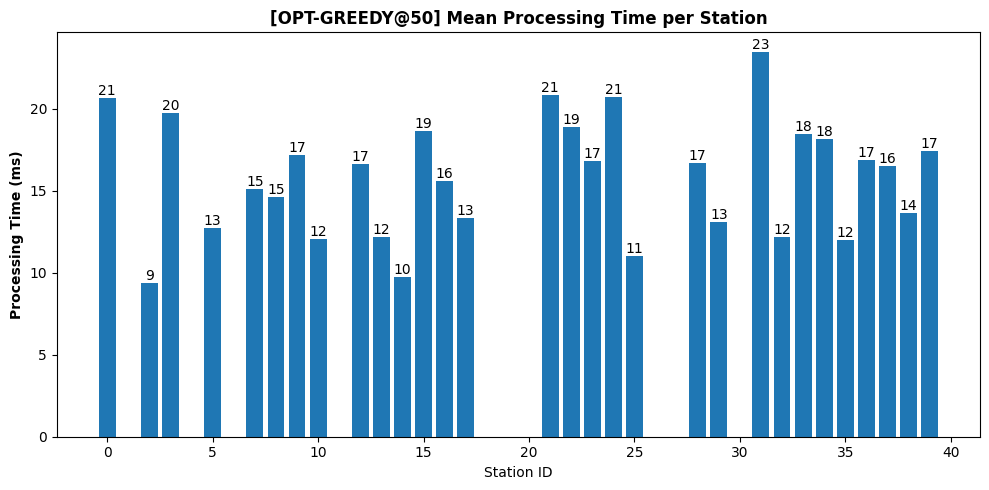

In [24]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [25]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/50cars


##### *Initialisation*

In [26]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [27]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:27:59.371 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-30 16:27:59.758 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-30 16:28:00.523 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-30 16:28:00.783 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-30 16:28:01.051 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-30 16:28:01.255 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-30 16:28:01.618 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-30 16:28:01.937 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-30 16:28:02.641 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-30 16:28:03.066 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-30 16:28:03.902 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [28]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 20.09 kWh
  Station 1: 9.38 kWh
  Station 2: 7.33 kWh
  Station 3: 14.49 kWh
  Station 4: 1.75 kWh
  Station 5: 19.76 kWh
  Station 6: 11.11 kWh
  Station 7: 8.16 kWh
  Station 8: 4.03 kWh
  Station 9: 0.00 kWh
  Station 10: 60.46 kWh
  Station 11: 3.67 kWh
  Station 12: 3.10 kWh
  Station 13: 3.15 kWh
  Station 14: 68.99 kWh
  Station 15: 12.72 kWh
  Station 16: 11.40 kWh
  Station 17: 2.91 kWh
  Station 18: 1.54 kWh
  Station 19: 4.03 kWh
  Station 20: 22.48 kWh
  Station 21: 0.00 kWh
  Station 22: 17.36 kWh
  Station 23: 1.92 kWh
  Station 24: 3.62 kWh
  Station 25: 30.88 kWh
  Station 26: 84.58 kWh
  Station 27: 0.00 kWh
  Station 28: 3.73 kWh
  Station 29: 1.33 kWh
  Station 30: 5.05 kWh
  Station 31: 2.23 kWh
  Station 32: 5.08 kWh
  Station 33: 4.40 kWh
  Station 34: 4.78 kWh
  Station 35: 0.00 kWh
  Station 36: 42.55 kWh
  Station 37: 12.08 kWh
  Station 38: 46.84 kWh
  Station 39: 4.19 kWh

--- User Re

In [29]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

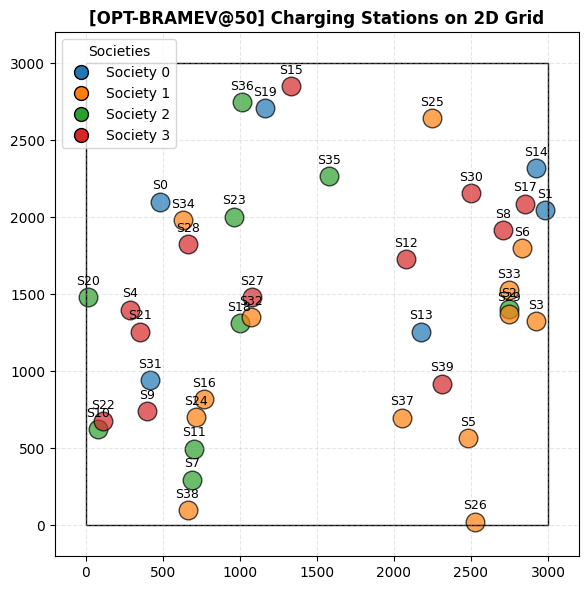

In [30]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

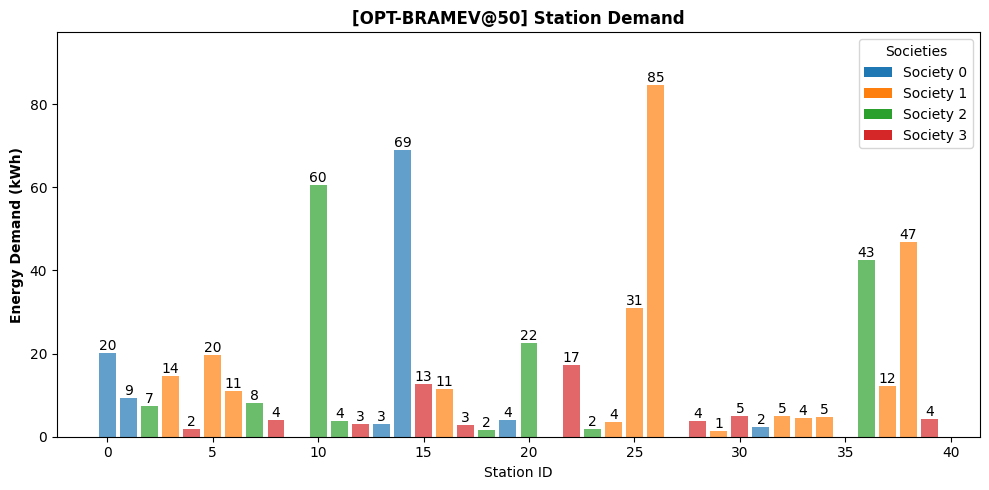

In [31]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

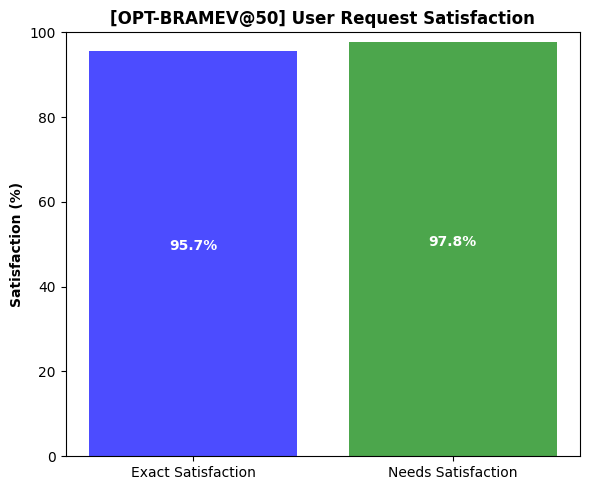

In [32]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

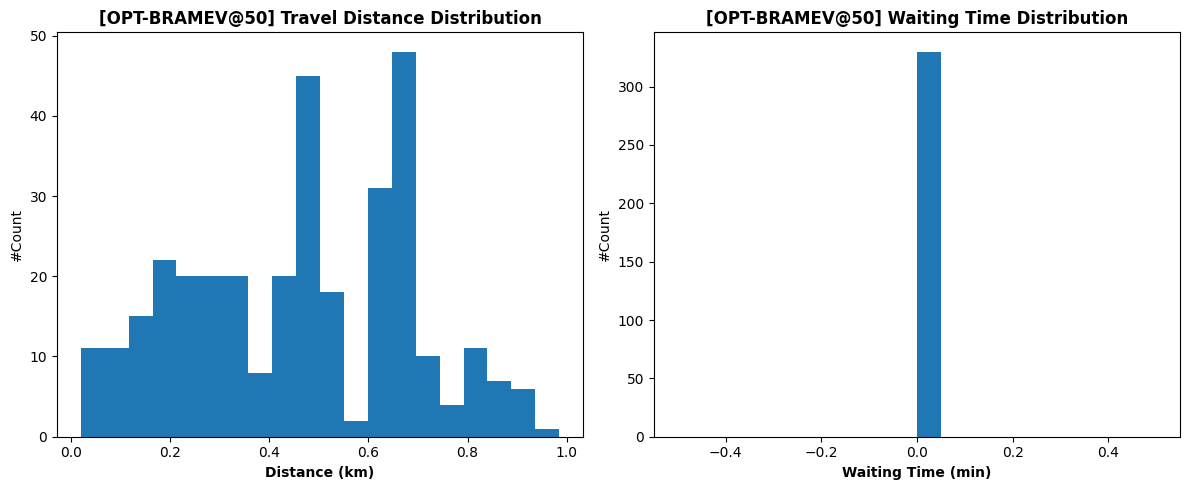

In [33]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

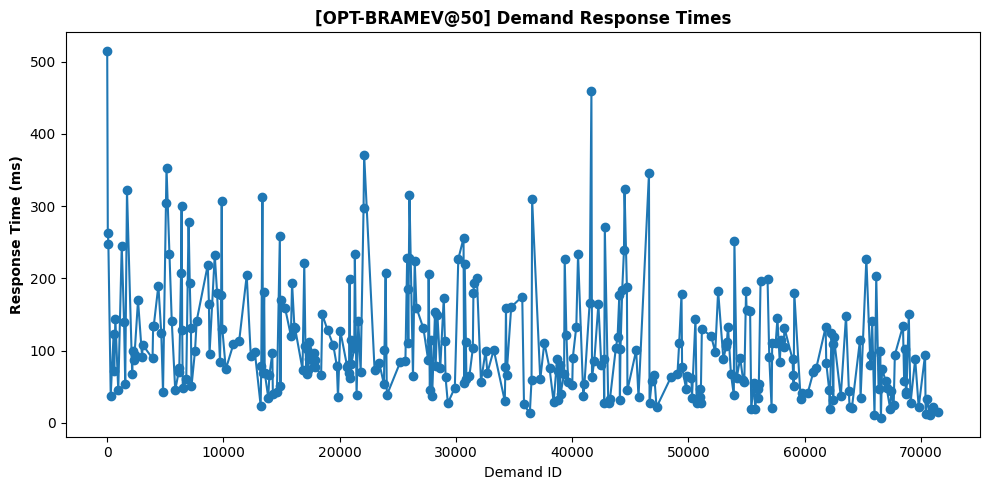

In [34]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

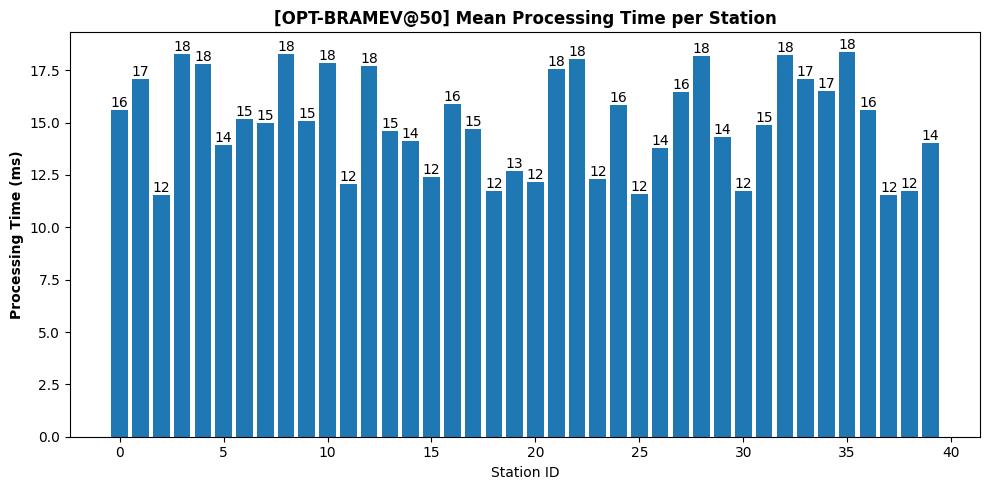

In [35]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

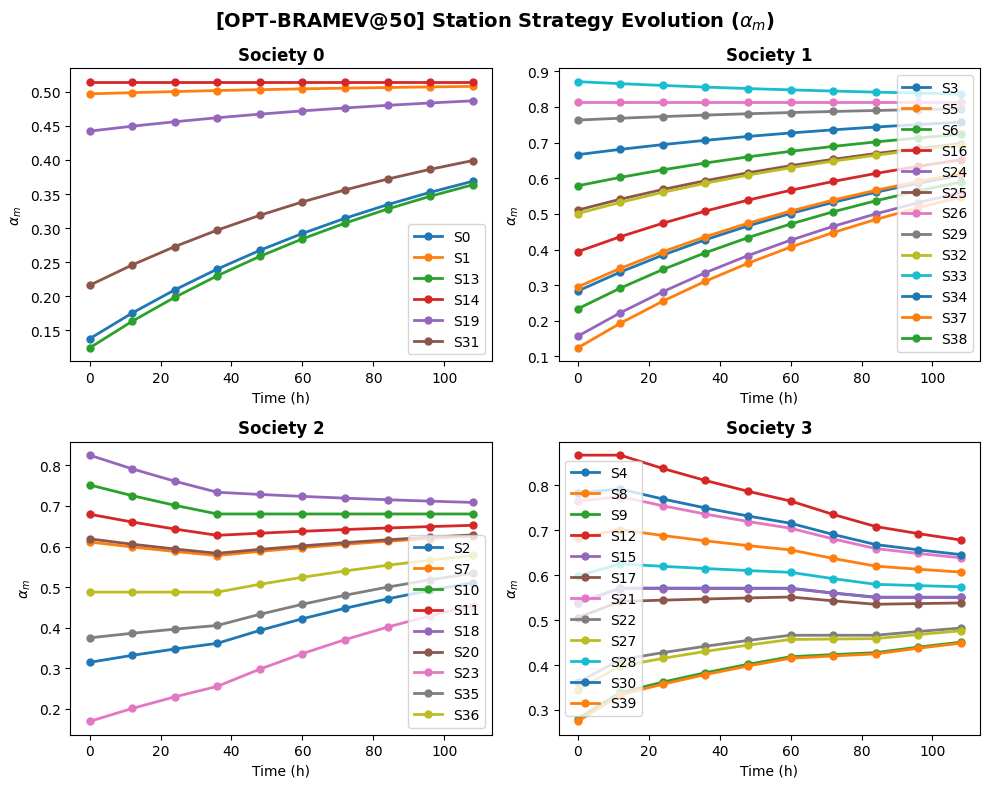

In [36]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [37]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

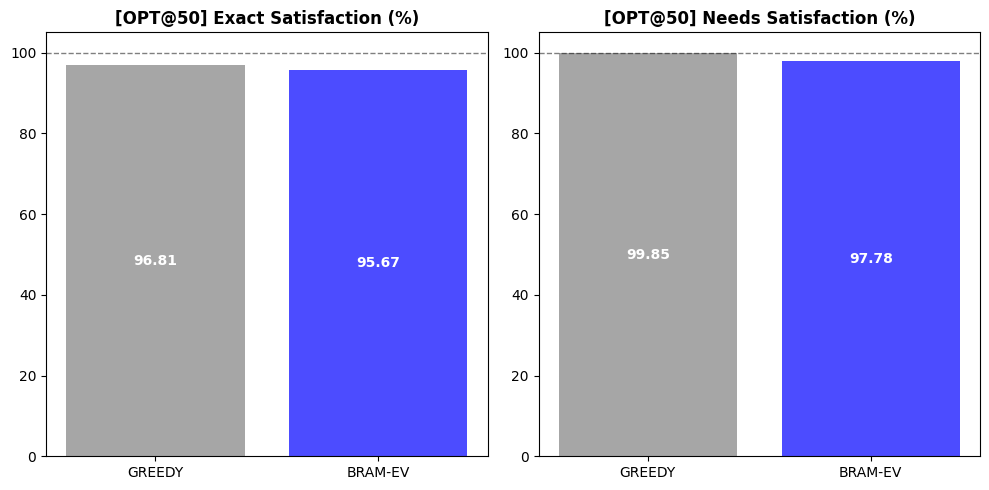

In [38]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

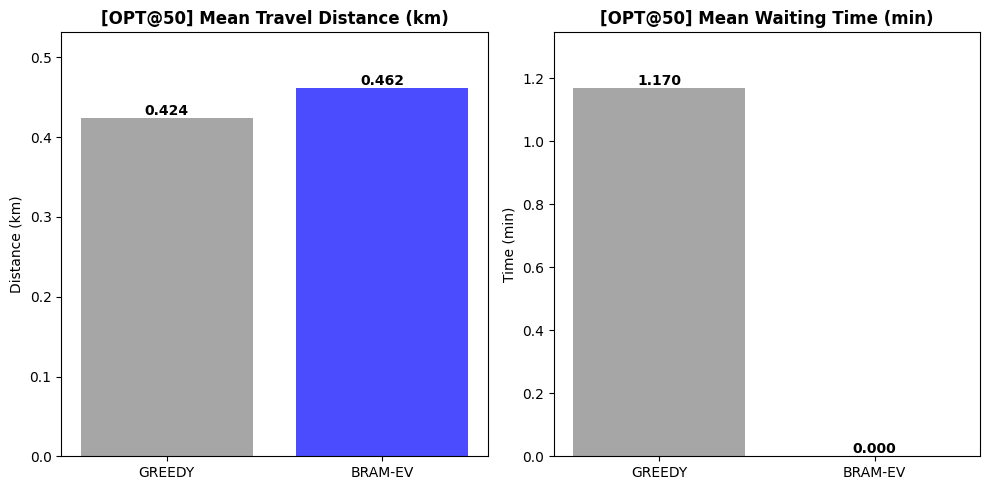

In [39]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

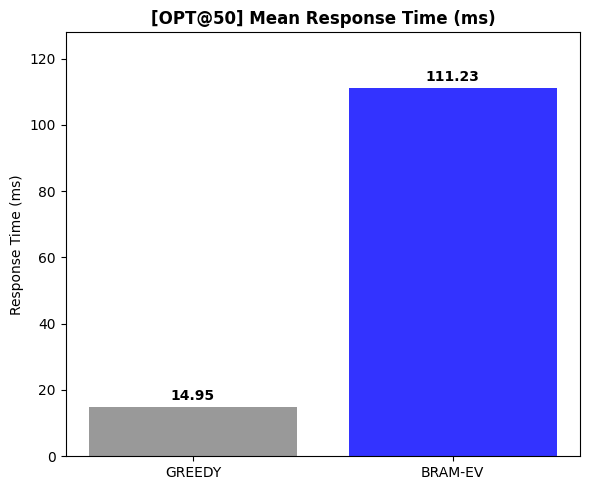

In [40]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [41]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [42]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/100cars


##### *Initialisation*

In [43]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [44]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:28:36.328 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-30 16:28:36.397 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-30 16:28:36.572 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-30 16:28:36.707 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-30 16:28:36.823 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-30 16:28:36.976 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-30 16:28:37.107 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-30 16:28:37.252 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-30 16:28:37.310 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-30 16:28:37.513 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-30 16:28:37.712 | IN

##### *Metrics*

In [45]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 24.76 kWh
  Station 1: 3.40 kWh
  Station 2: 16.19 kWh
  Station 3: 33.67 kWh
  Station 4: 3.81 kWh
  Station 5: 1.07 kWh
  Station 6: 23.17 kWh
  Station 7: 19.14 kWh
  Station 8: 0.00 kWh
  Station 9: 1.05 kWh
  Station 10: 3.11 kWh
  Station 11: 20.08 kWh
  Station 12: 0.00 kWh
  Station 13: 5.58 kWh
  Station 14: 24.02 kWh
  Station 15: 2.13 kWh
  Station 16: 13.89 kWh
  Station 17: 32.63 kWh
  Station 18: 31.11 kWh
  Station 19: 4.37 kWh
  Station 20: 21.91 kWh
  Station 21: 94.24 kWh
  Station 22: 25.46 kWh
  Station 23: 35.89 kWh
  Station 24: 61.19 kWh
  Station 25: 150.27 kWh
  Station 26: 36.58 kWh
  Station 27: 17.50 kWh
  Station 28: 1.65 kWh
  Station 29: 39.93 kWh
  Station 30: 165.02 kWh
  Station 31: 2.30 kWh
  Station 32: 1.46 kWh
  Station 33: 6.15 kWh
  Station 34: 11.12 kWh
  Station 35: 7.70 kWh
  Station 36: 4.67 kWh
  Station 37: 153.73 kWh
  Station 38: 10.63 kWh
  Station 39: 4.42 kWh



In [46]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

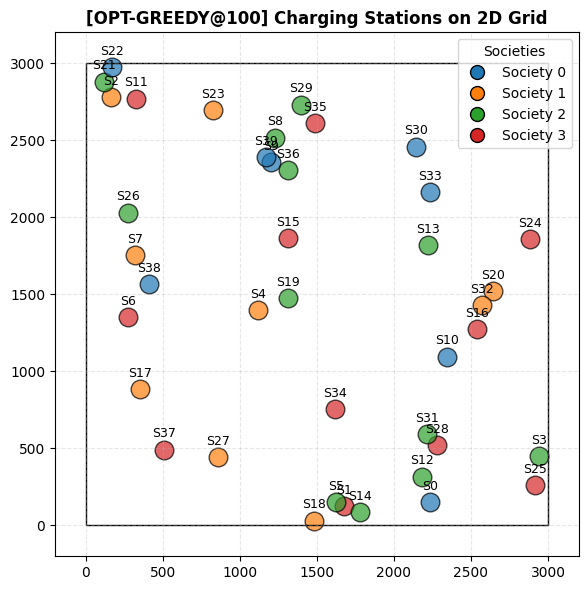

In [47]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

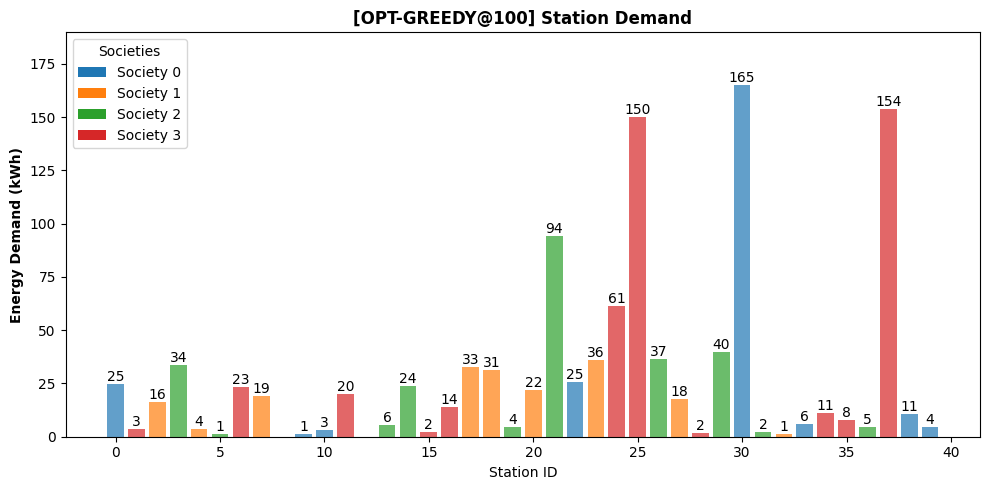

In [48]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

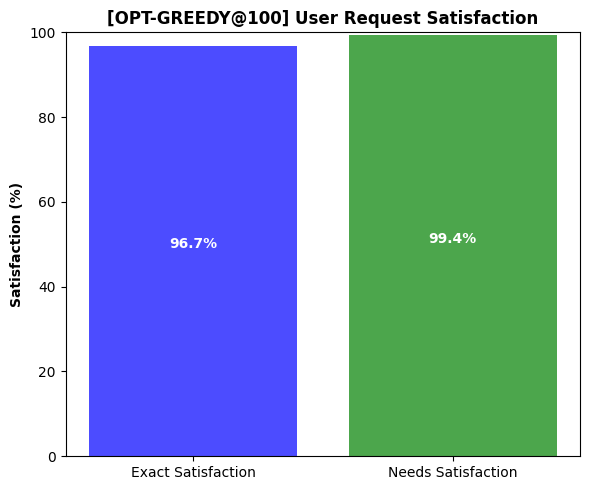

In [49]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

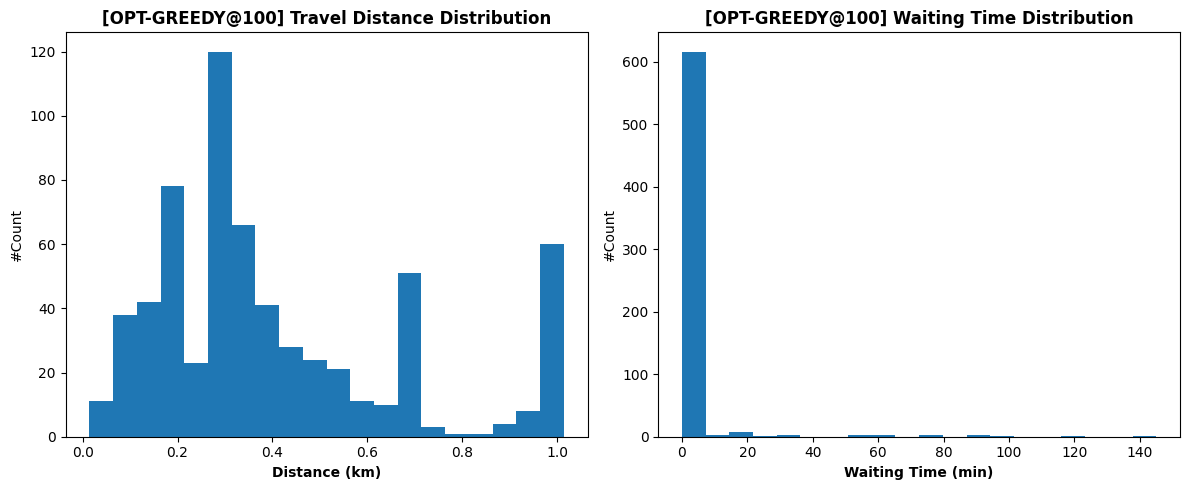

In [50]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

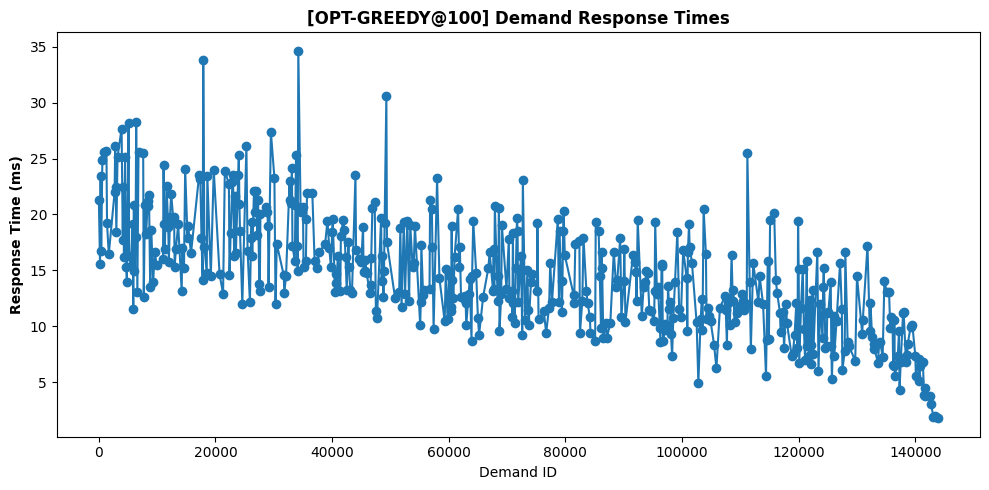

In [51]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

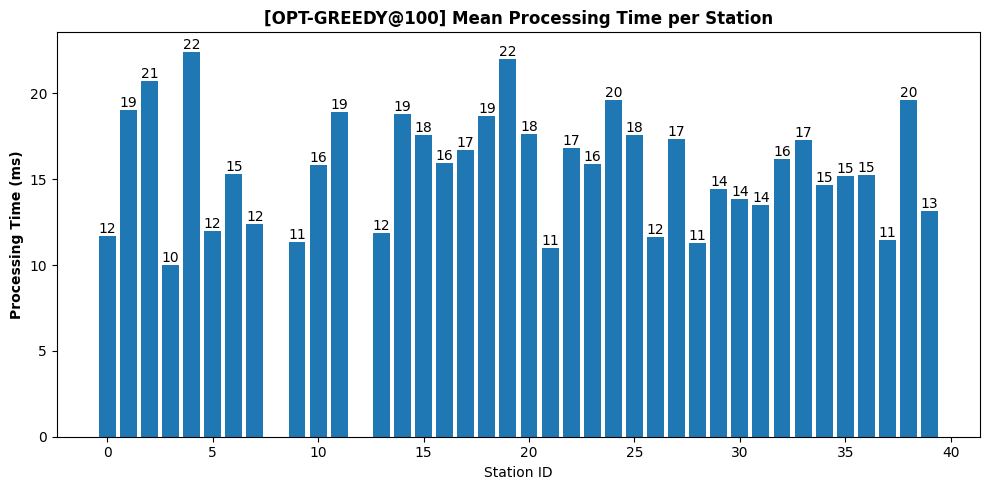

In [52]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [53]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/100cars


##### *Initialisation*

In [54]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [55]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:28:49.776 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-30 16:28:50.533 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-30 16:28:51.580 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-30 16:28:51.950 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-30 16:28:53.386 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-30 16:28:54.222 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-30 16:28:55.377 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-30 16:28:56.035 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-30 16:28:56.862 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-30 16:28:58.005 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-30 16:28:58.690 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [56]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 0.00 kWh
  Station 1: 1.93 kWh
  Station 2: 42.63 kWh
  Station 3: 4.79 kWh
  Station 4: 2.35 kWh
  Station 5: 31.46 kWh
  Station 6: 1.63 kWh
  Station 7: 152.38 kWh
  Station 8: 3.15 kWh
  Station 9: 50.12 kWh
  Station 10: 1.53 kWh
  Station 11: 117.40 kWh
  Station 12: 2.51 kWh
  Station 13: 124.88 kWh
  Station 14: 40.81 kWh
  Station 15: 5.41 kWh
  Station 16: 4.07 kWh
  Station 17: 8.82 kWh
  Station 18: 145.22 kWh
  Station 19: 2.00 kWh
  Station 20: 52.61 kWh
  Station 21: 7.50 kWh
  Station 22: 5.14 kWh
  Station 23: 3.23 kWh
  Station 24: 19.38 kWh
  Station 25: 3.42 kWh
  Station 26: 45.67 kWh
  Station 27: 14.26 kWh
  Station 28: 14.22 kWh
  Station 29: 26.56 kWh
  Station 30: 24.12 kWh
  Station 31: 22.79 kWh
  Station 32: 19.78 kWh
  Station 33: 6.24 kWh
  Station 34: 41.16 kWh
  Station 35: 17.86 kWh
  Station 36: 5.04 kWh
  Station 37: 7.06 kWh
  Station 38: 37.55 kWh
  Station 39: 19.23 kWh

-

In [57]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

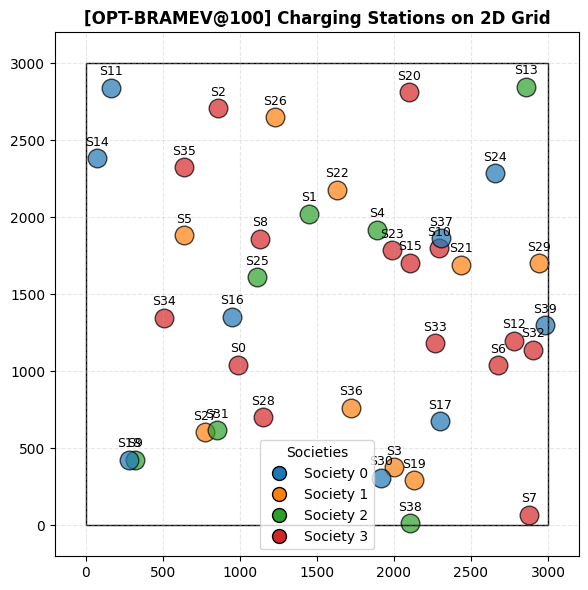

In [58]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

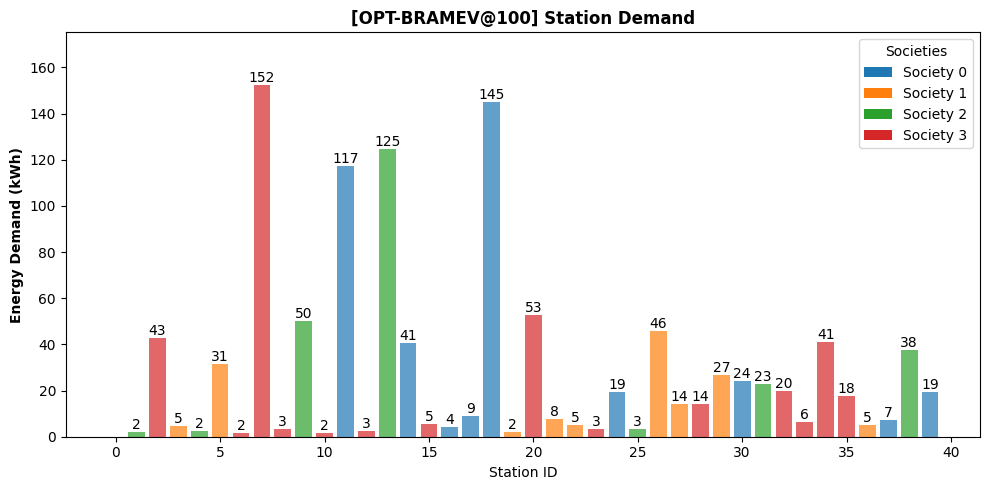

In [59]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

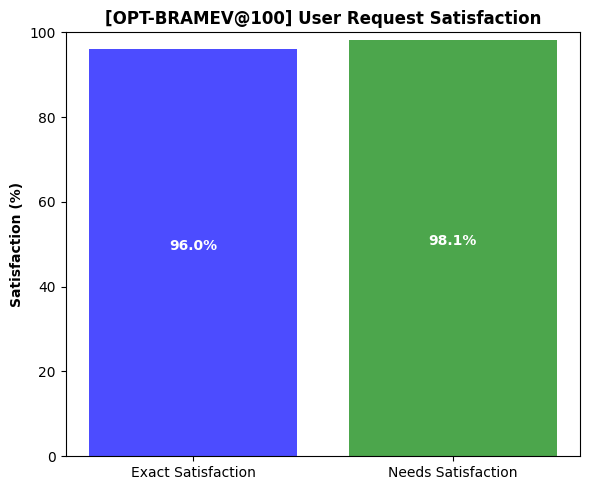

In [60]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

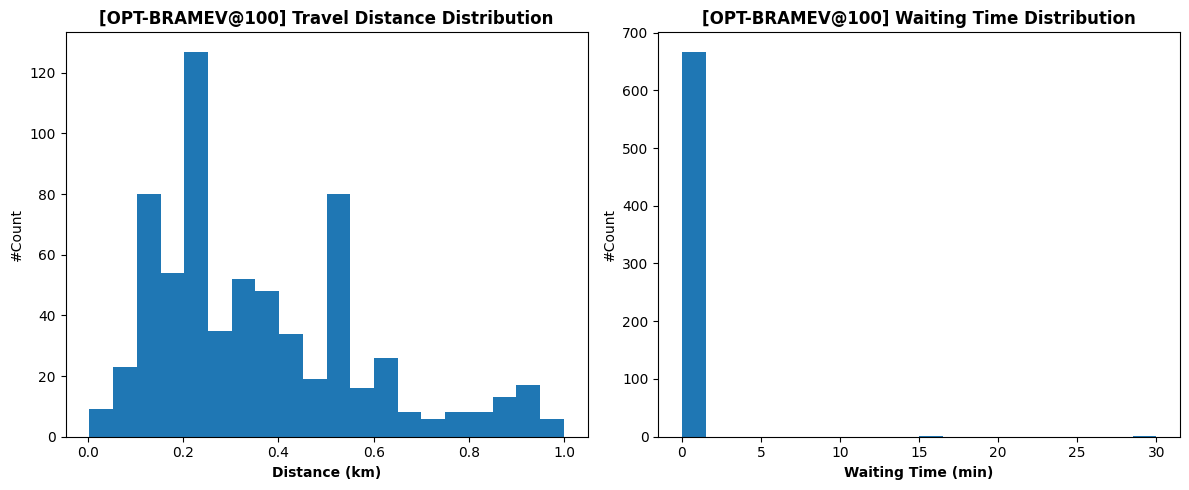

In [61]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

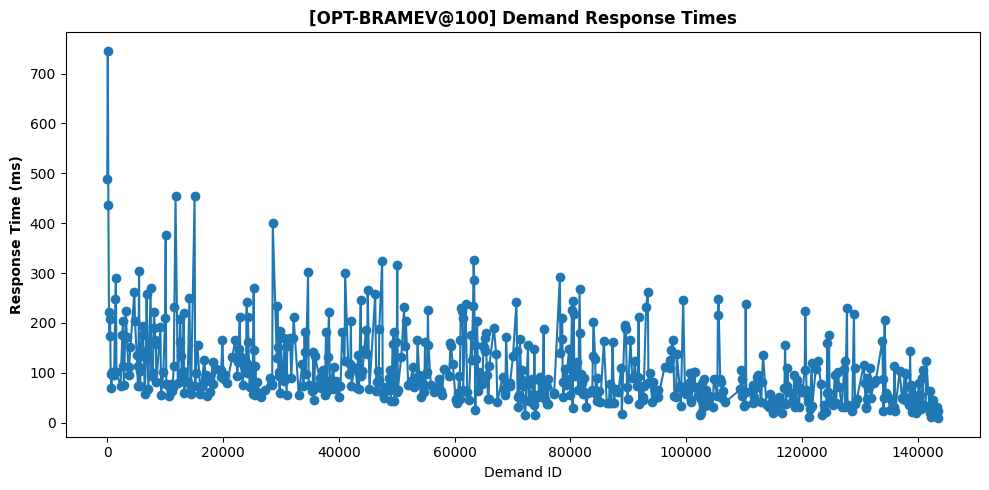

In [62]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

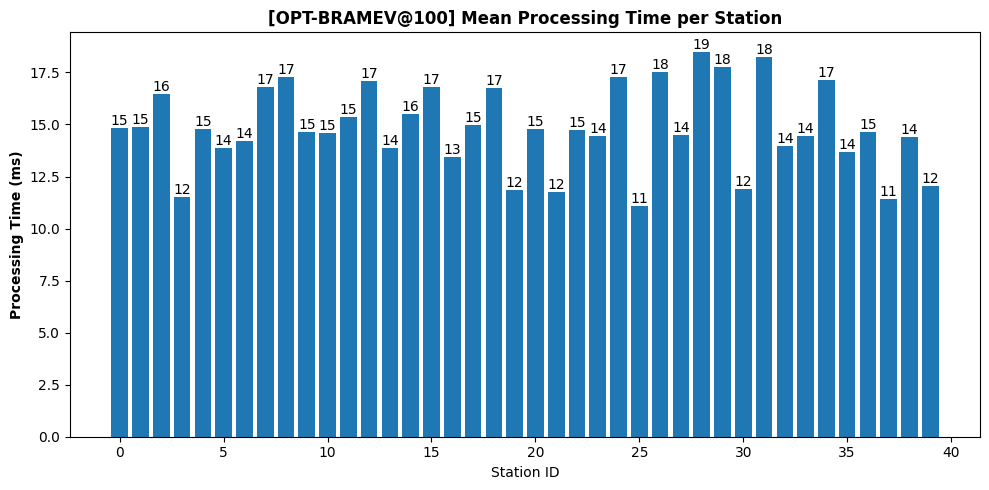

In [63]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

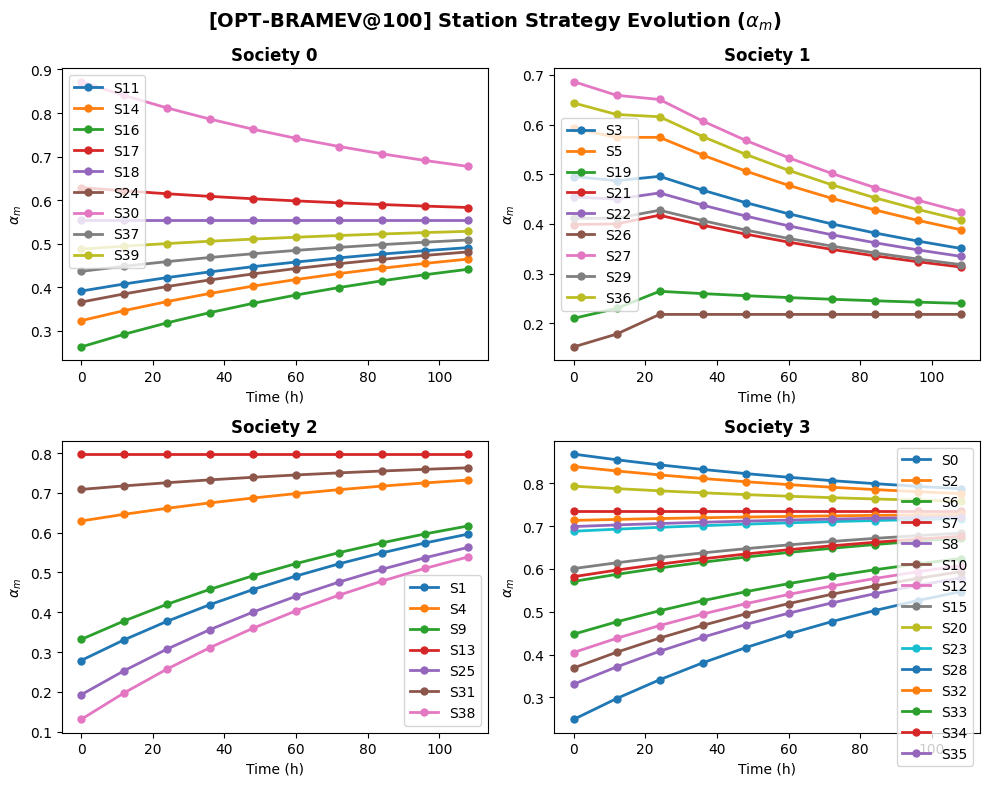

In [64]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [65]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

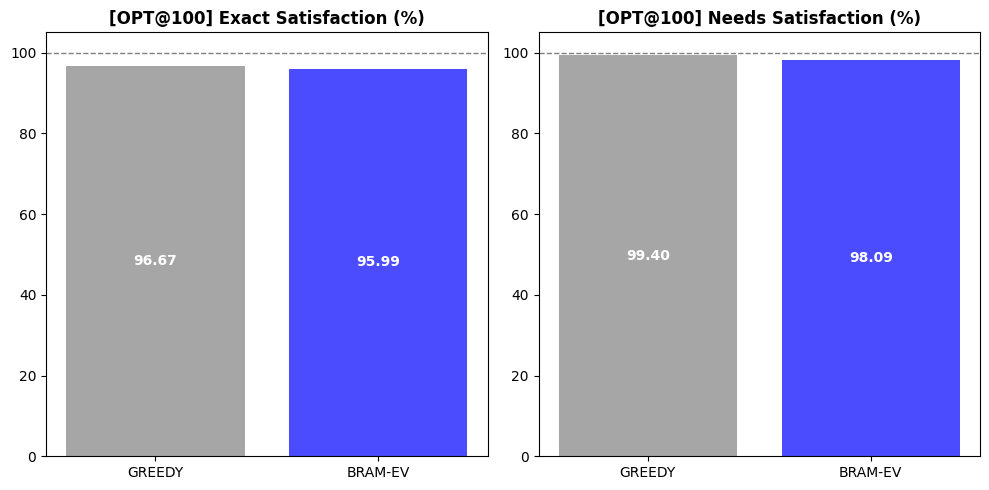

In [66]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

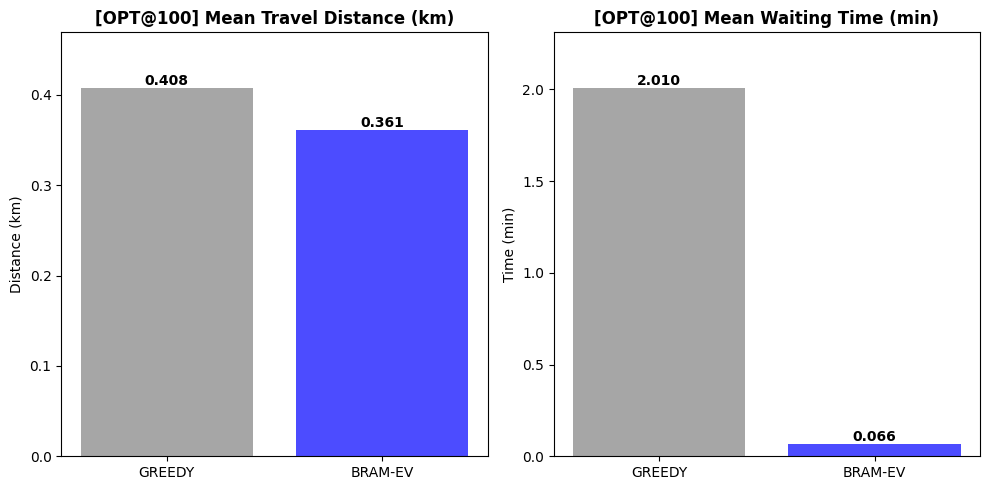

In [67]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

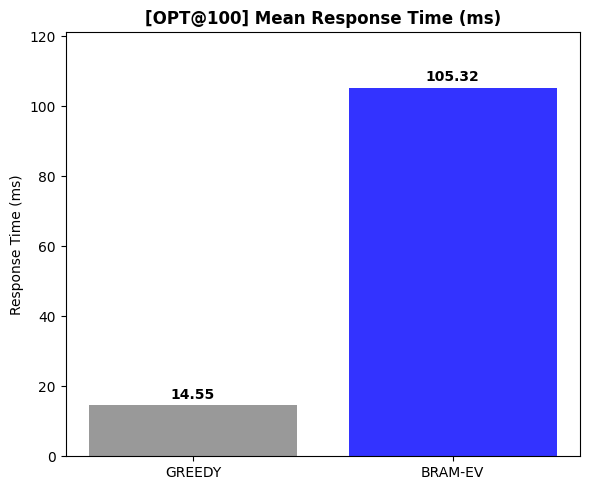

In [68]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [69]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [70]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/150cars


##### *Initialisation*

In [71]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [72]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:29:53.732 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-30 16:29:53.898 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-30 16:29:54.076 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-30 16:29:54.267 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-30 16:29:54.444 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-30 16:29:54.692 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-30 16:29:54.992 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-30 16:29:55.269 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-30 16:29:55.441 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-30 16:29:55.628 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-30 16:29:55.755 | IN

##### *Metrics*

In [73]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 4.61 kWh
  Station 1: 49.08 kWh
  Station 2: 3.23 kWh
  Station 3: 0.58 kWh
  Station 4: 6.57 kWh
  Station 5: 242.35 kWh
  Station 6: 57.98 kWh
  Station 7: 6.79 kWh
  Station 8: 36.35 kWh
  Station 9: 29.18 kWh
  Station 10: 1.67 kWh
  Station 11: 0.00 kWh
  Station 12: 265.26 kWh
  Station 13: 12.88 kWh
  Station 14: 47.47 kWh
  Station 15: 40.92 kWh
  Station 16: 9.43 kWh
  Station 17: 2.60 kWh
  Station 18: 2.60 kWh
  Station 19: 10.79 kWh
  Station 20: 28.73 kWh
  Station 21: 202.96 kWh
  Station 22: 15.00 kWh
  Station 23: 33.67 kWh
  Station 24: 70.14 kWh
  Station 25: 70.37 kWh
  Station 26: 14.82 kWh
  Station 27: 50.90 kWh
  Station 28: 16.30 kWh
  Station 29: 17.57 kWh
  Station 30: 10.25 kWh
  Station 31: 1.40 kWh
  Station 32: 2.98 kWh
  Station 33: 8.27 kWh
  Station 34: 5.77 kWh
  Station 35: 6.06 kWh
  Station 36: 184.78 kWh
  Station 37: 49.55 kWh
  Station 38: 4.62 kWh
  Station 39: 25.29 kWh

In [74]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

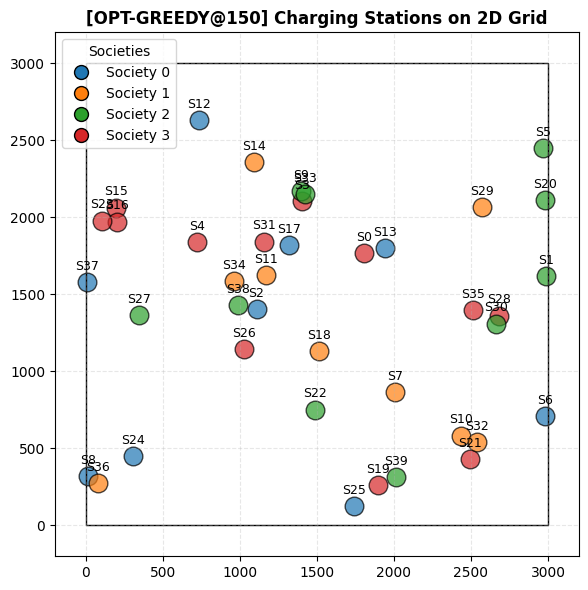

In [75]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

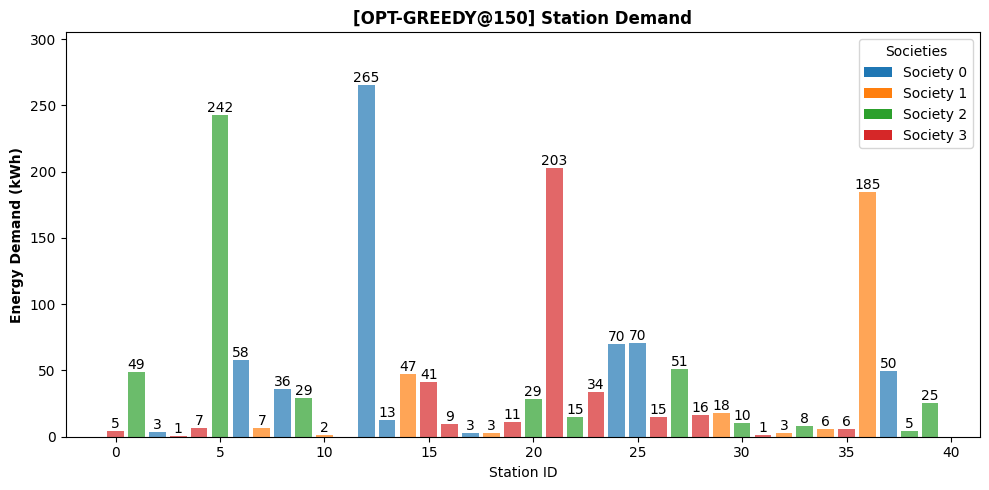

In [76]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

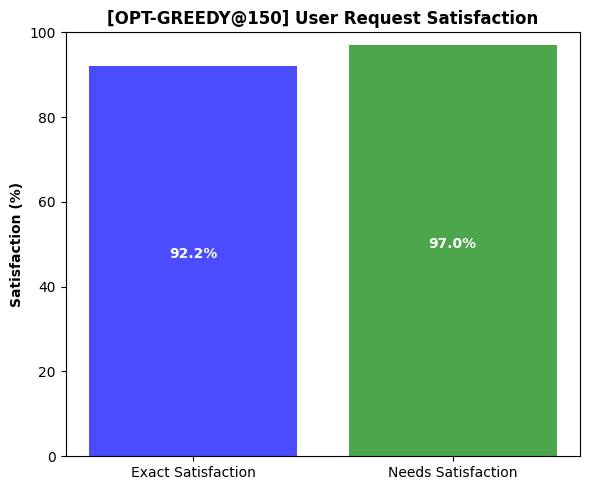

In [77]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

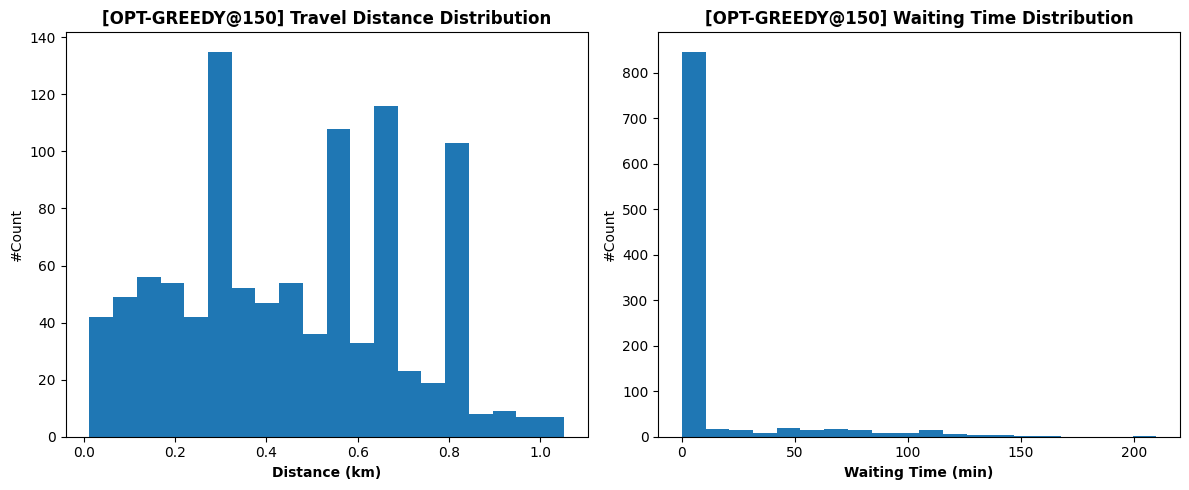

In [78]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

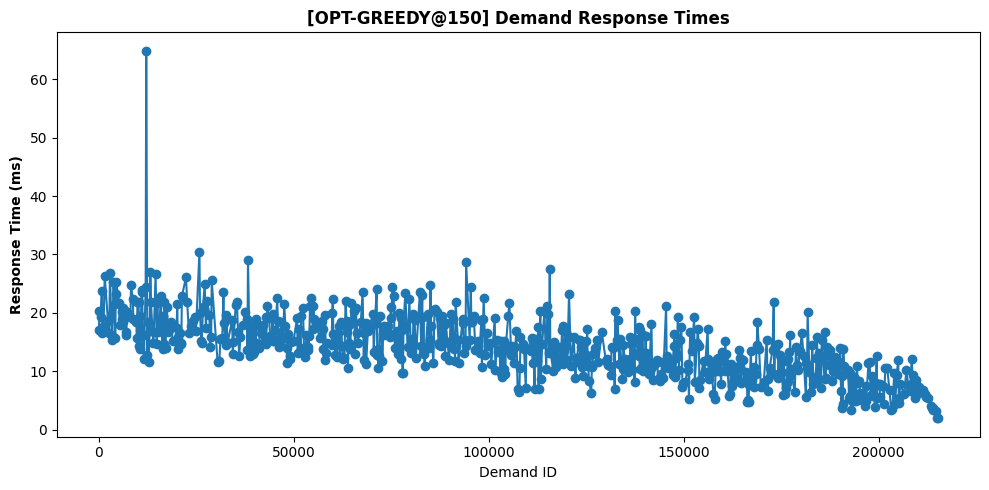

In [79]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

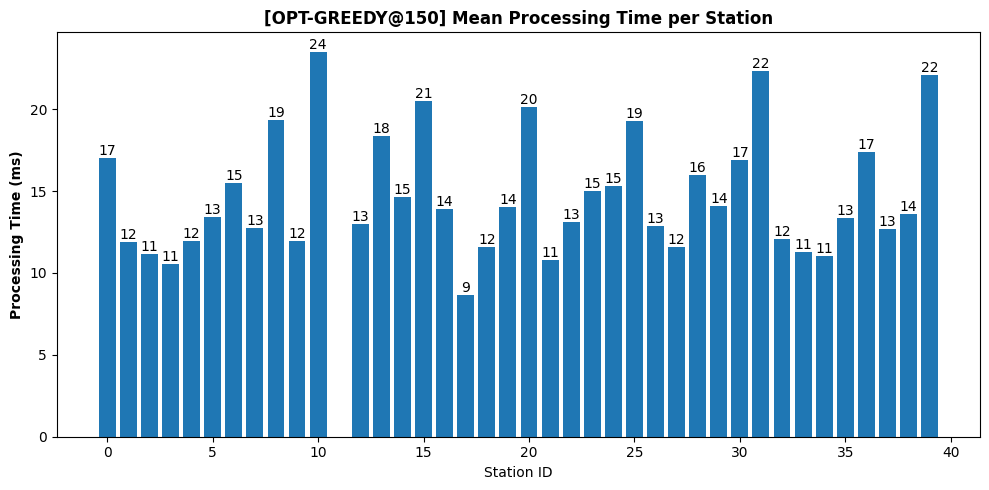

In [80]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [81]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/150cars


##### *Initialisation*

In [82]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [83]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:30:14.673 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-30 16:30:16.380 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-30 16:30:18.089 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-30 16:30:18.888 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-30 16:30:19.865 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-30 16:30:20.494 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-30 16:30:21.736 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-30 16:30:22.525 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-30 16:30:23.413 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-30 16:30:23.817 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-30 16:30:25.509 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [84]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 8.30 kWh
  Station 1: 16.07 kWh
  Station 2: 31.70 kWh
  Station 3: 157.62 kWh
  Station 4: 11.79 kWh
  Station 5: 217.38 kWh
  Station 6: 52.05 kWh
  Station 7: 42.96 kWh
  Station 8: 77.93 kWh
  Station 9: 174.61 kWh
  Station 10: 62.91 kWh
  Station 11: 6.63 kWh
  Station 12: 4.74 kWh
  Station 13: 42.33 kWh
  Station 14: 1.42 kWh
  Station 15: 6.51 kWh
  Station 16: 5.58 kWh
  Station 17: 51.83 kWh
  Station 18: 21.00 kWh
  Station 19: 7.53 kWh
  Station 20: 2.78 kWh
  Station 21: 80.08 kWh
  Station 22: 4.07 kWh
  Station 23: 188.95 kWh
  Station 24: 55.90 kWh
  Station 25: 9.54 kWh
  Station 26: 15.91 kWh
  Station 27: 17.30 kWh
  Station 28: 82.70 kWh
  Station 29: 35.28 kWh
  Station 30: 5.48 kWh
  Station 31: 48.71 kWh
  Station 32: 5.52 kWh
  Station 33: 12.14 kWh
  Station 34: 5.94 kWh
  Station 35: 49.91 kWh
  Station 36: 17.23 kWh
  Station 37: 2.07 kWh
  Station 38: 4.14 kWh
  Station 39: 29.98 kW

In [85]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

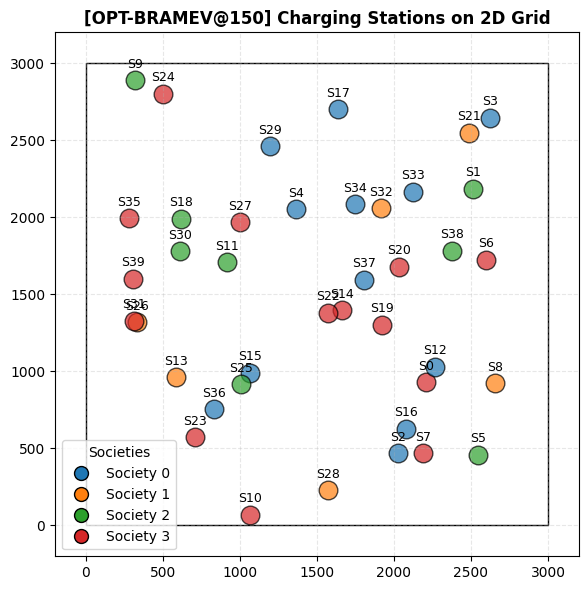

In [86]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

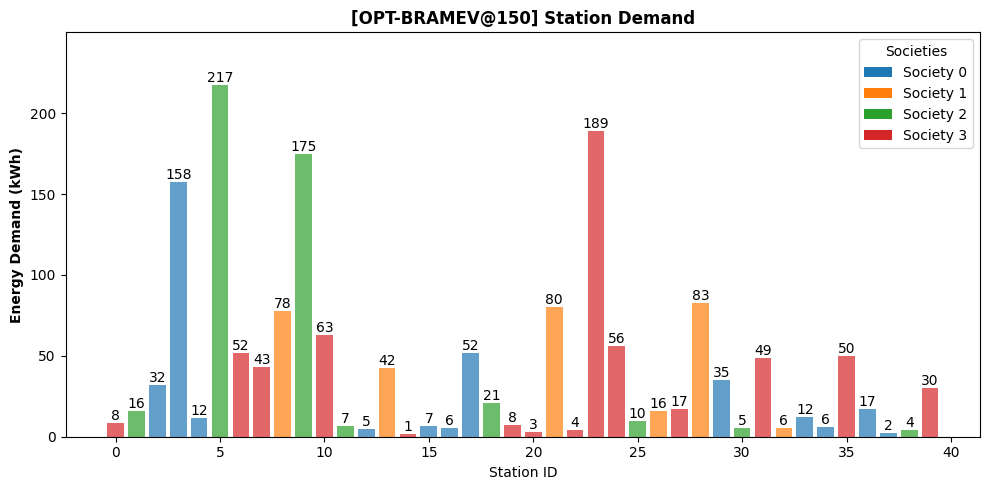

In [87]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

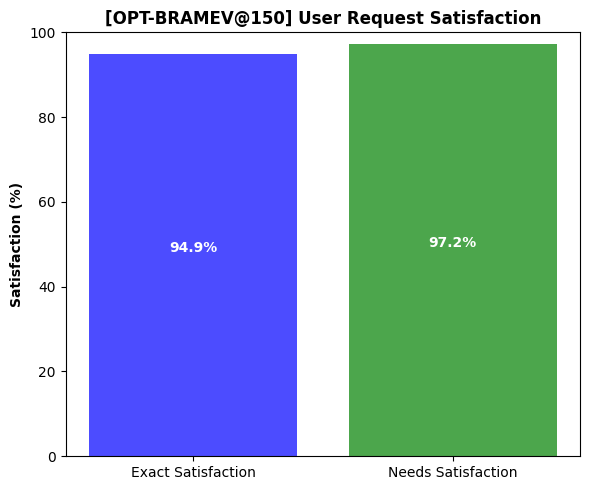

In [88]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

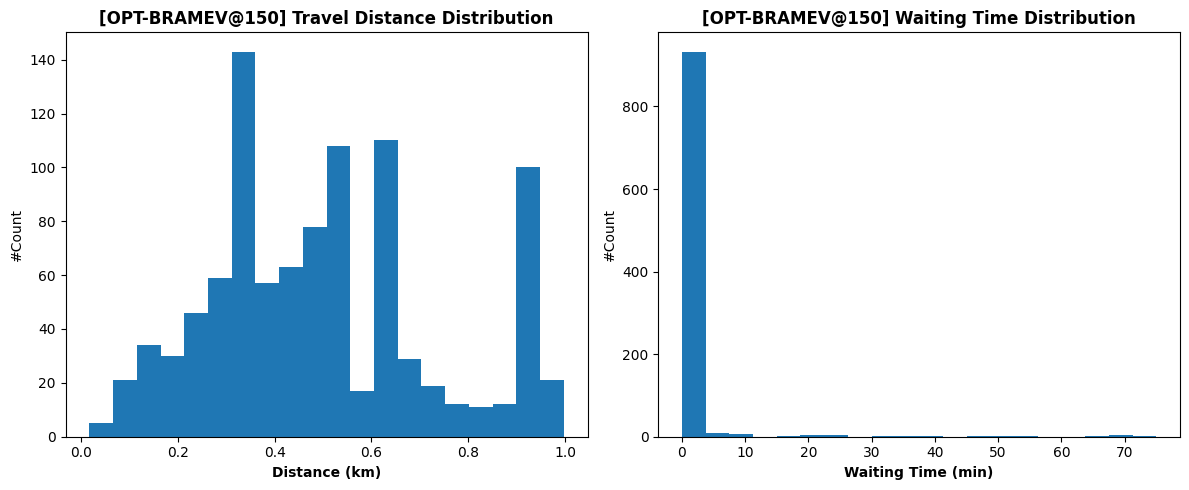

In [89]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

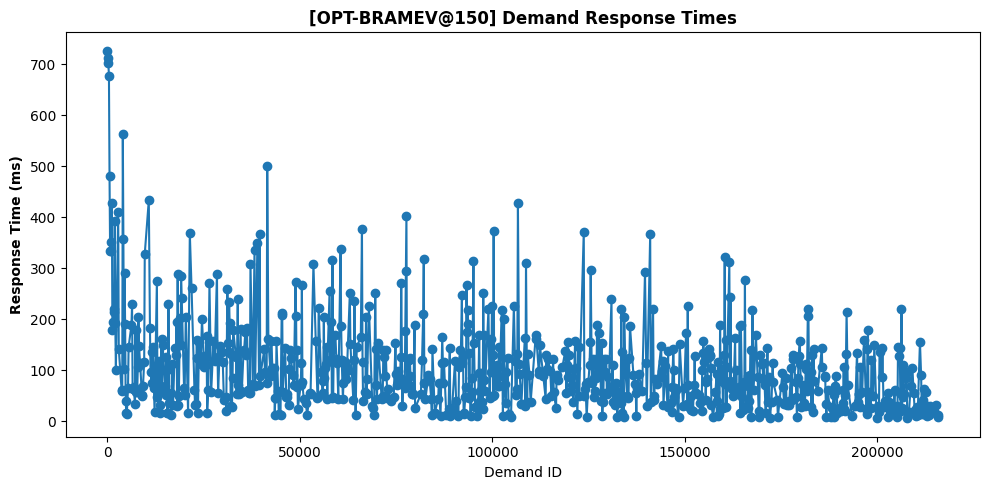

In [90]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

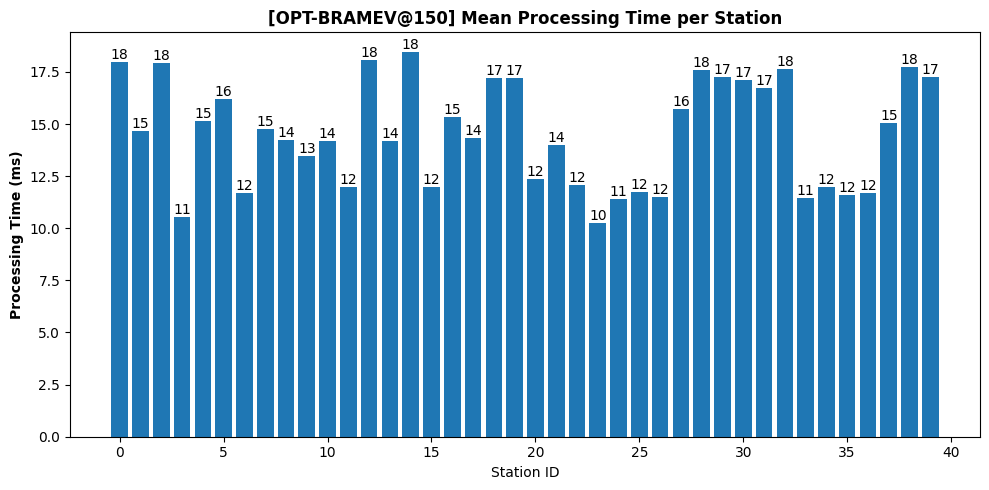

In [91]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

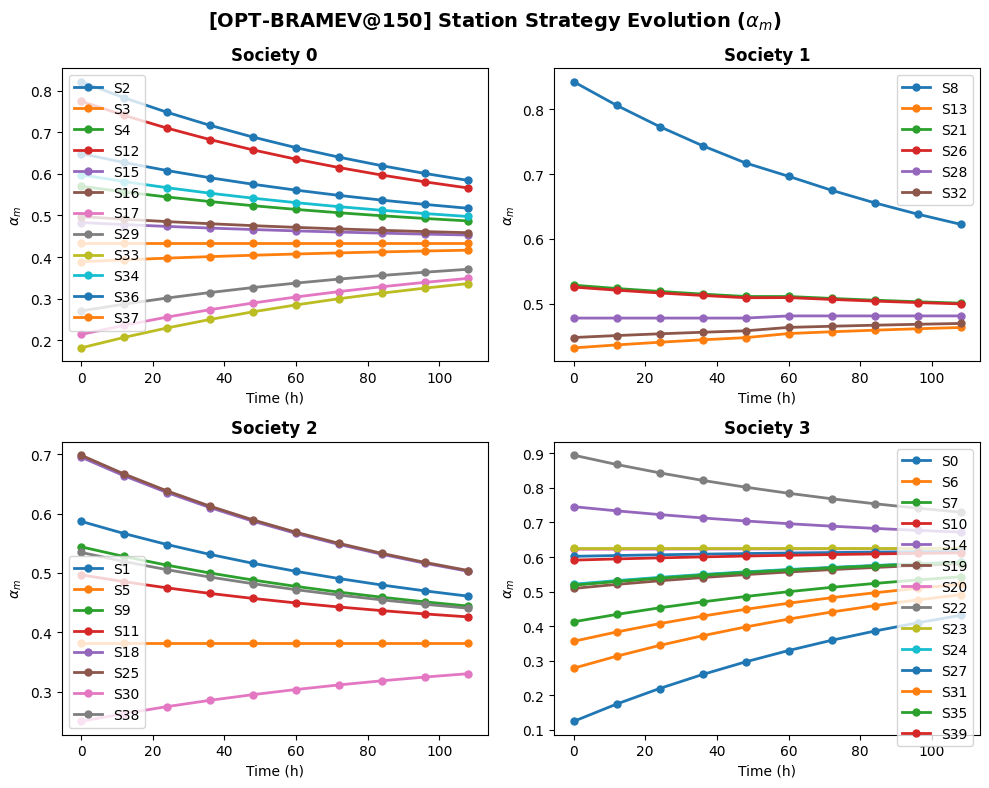

In [92]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [93]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

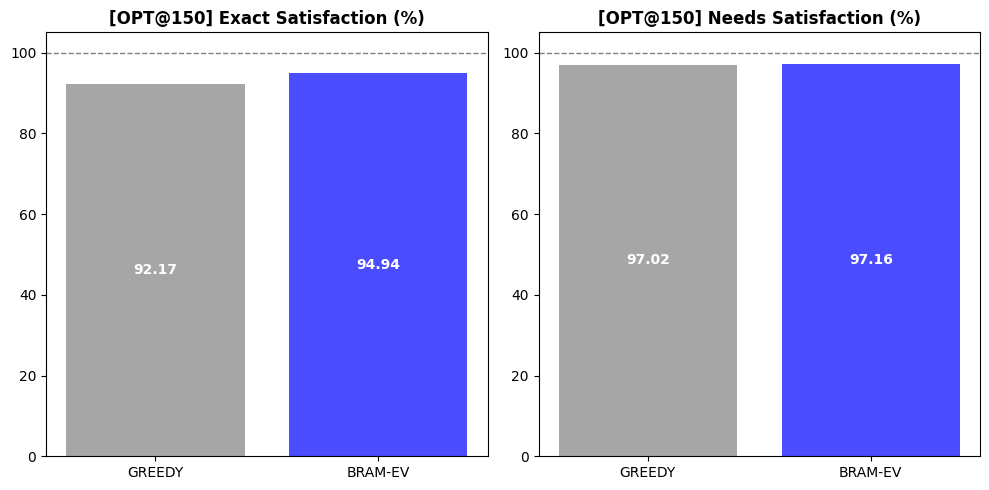

In [94]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

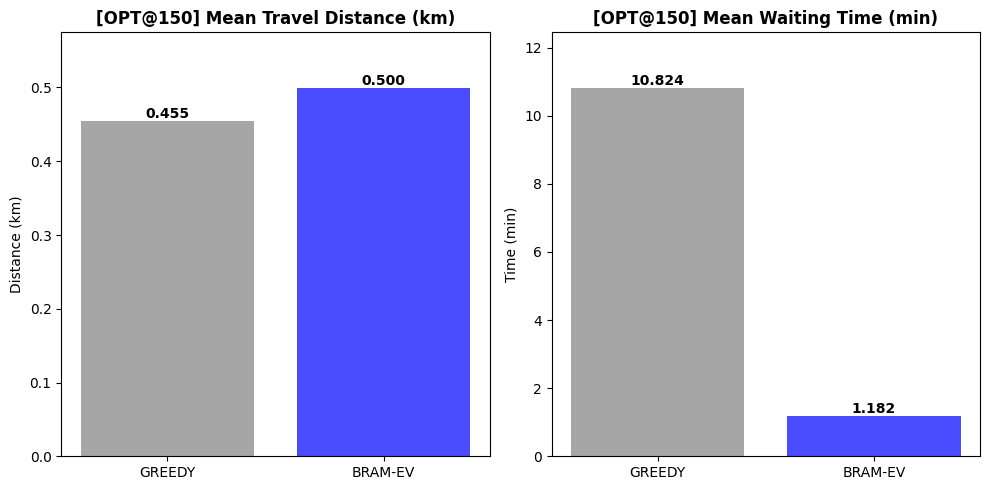

In [95]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

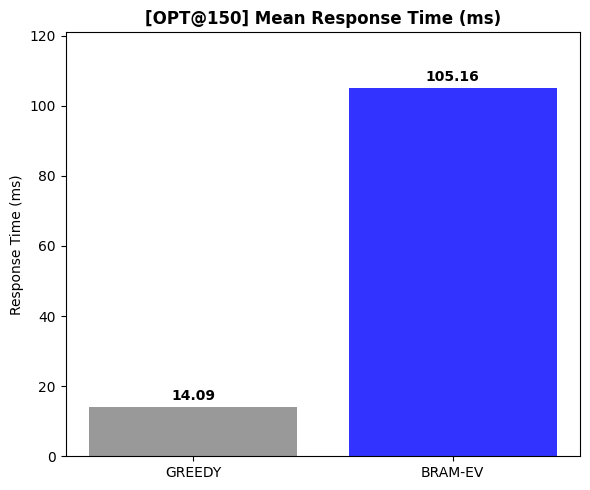

In [96]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [97]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [98]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/200cars


##### *Initialisation*

In [99]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [100]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:31:35.350 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-30 16:31:35.744 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-30 16:31:35.906 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-30 16:31:36.132 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-30 16:31:36.483 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-30 16:31:36.748 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-30 16:31:36.909 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-30 16:31:37.162 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-30 16:31:37.475 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-30 16:31:37.690 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-30 16:31:37.986 | IN

##### *Metrics*

In [101]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 148.32 kWh
  Station 1: 1.43 kWh
  Station 2: 48.10 kWh
  Station 3: 51.42 kWh
  Station 4: 1.70 kWh
  Station 5: 252.89 kWh
  Station 6: 129.51 kWh
  Station 7: 3.29 kWh
  Station 8: 147.55 kWh
  Station 9: 2.77 kWh
  Station 10: 9.65 kWh
  Station 11: 8.38 kWh
  Station 12: 267.19 kWh
  Station 13: 0.00 kWh
  Station 14: 16.05 kWh
  Station 15: 3.27 kWh
  Station 16: 8.58 kWh
  Station 17: 9.19 kWh
  Station 18: 0.00 kWh
  Station 19: 2.22 kWh
  Station 20: 8.14 kWh
  Station 21: 7.75 kWh
  Station 22: 3.65 kWh
  Station 23: 0.00 kWh
  Station 24: 338.43 kWh
  Station 25: 2.70 kWh
  Station 26: 18.37 kWh
  Station 27: 49.11 kWh
  Station 28: 47.40 kWh
  Station 29: 73.95 kWh
  Station 30: 3.92 kWh
  Station 31: 67.53 kWh
  Station 32: 13.50 kWh
  Station 33: 6.33 kWh
  Station 34: 9.84 kWh
  Station 35: 271.94 kWh
  Station 36: 26.14 kWh
  Station 37: 6.62 kWh
  Station 38: 11.03 kWh
  Station 39: 44.72 kWh



In [102]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

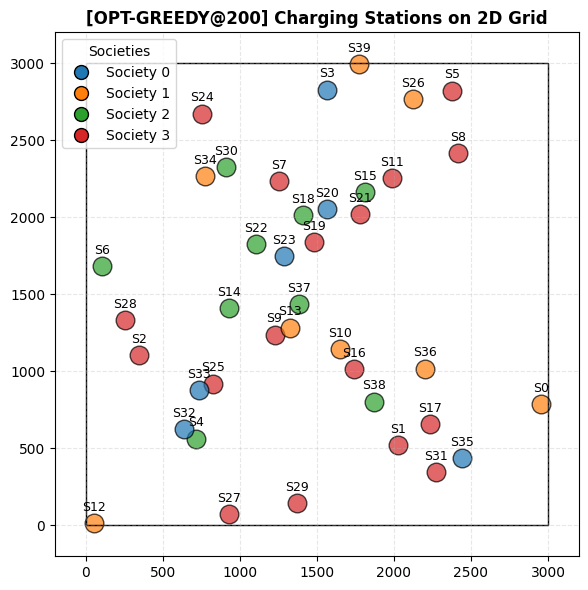

In [103]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

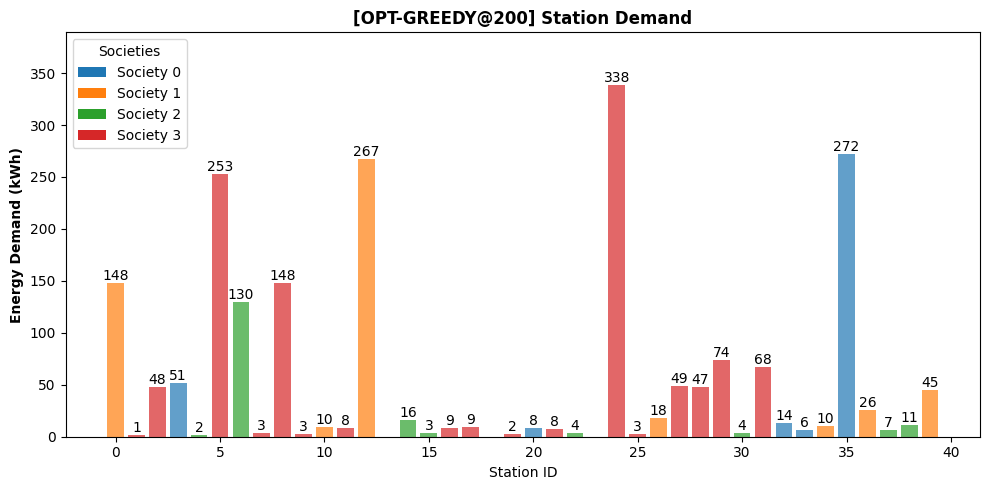

In [104]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

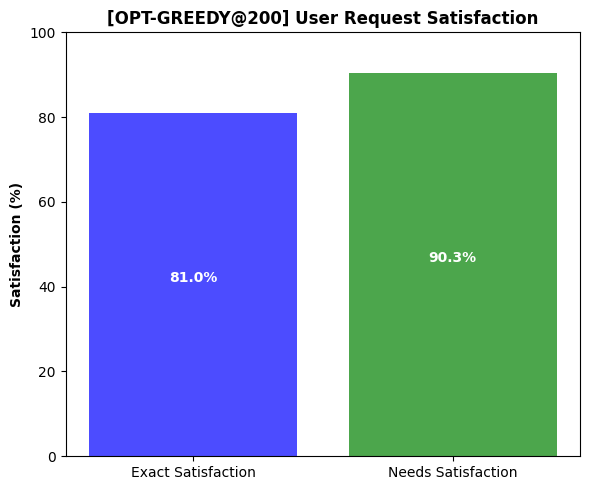

In [105]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

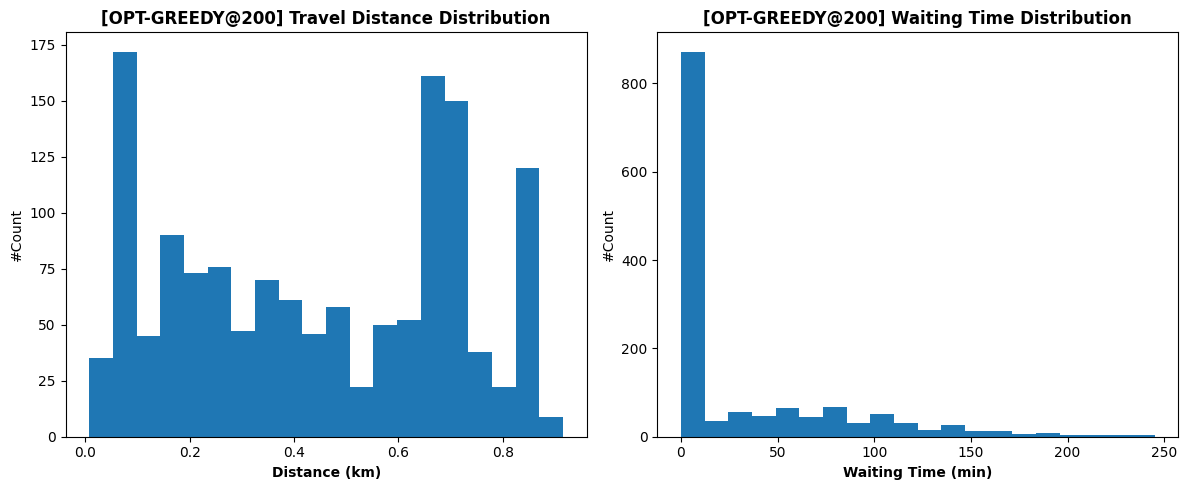

In [106]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

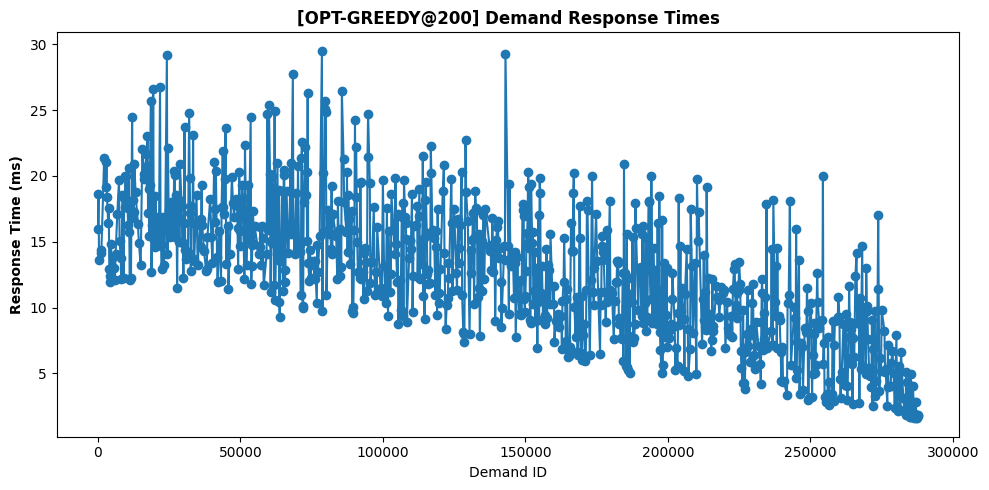

In [107]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

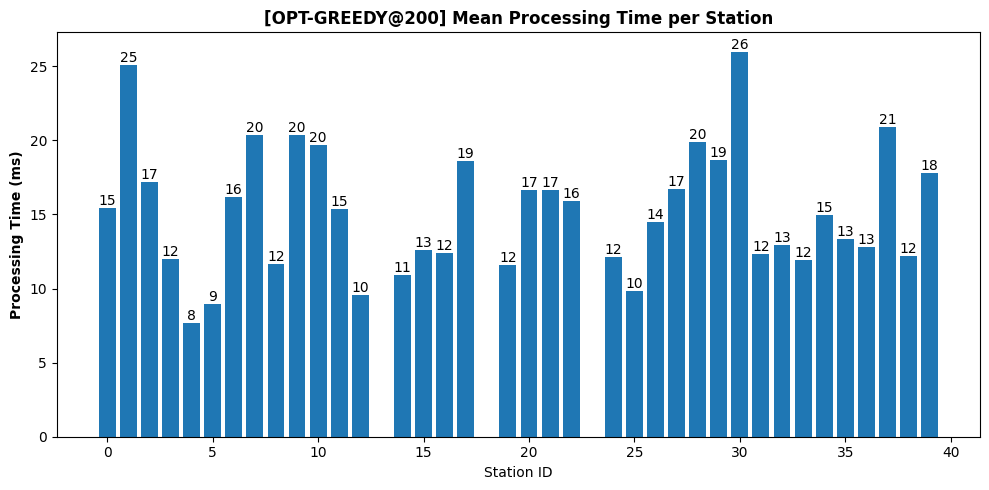

In [108]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [109]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/200cars


##### *Initialisation*

In [110]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [111]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:32:03.119 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-30 16:32:05.162 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-30 16:32:07.835 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-30 16:32:09.308 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-30 16:32:10.522 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-30 16:32:12.218 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-30 16:32:13.778 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-30 16:32:14.557 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-30 16:32:16.557 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-30 16:32:17.700 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-30 16:32:19.754 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [112]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 16.94 kWh
  Station 1: 234.39 kWh
  Station 2: 15.90 kWh
  Station 3: 8.18 kWh
  Station 4: 8.79 kWh
  Station 5: 56.62 kWh
  Station 6: 4.55 kWh
  Station 7: 14.58 kWh
  Station 8: 89.67 kWh
  Station 9: 51.01 kWh
  Station 10: 31.38 kWh
  Station 11: 61.24 kWh
  Station 12: 7.42 kWh
  Station 13: 21.27 kWh
  Station 14: 26.49 kWh
  Station 15: 6.27 kWh
  Station 16: 8.89 kWh
  Station 17: 34.83 kWh
  Station 18: 24.65 kWh
  Station 19: 3.42 kWh
  Station 20: 4.20 kWh
  Station 21: 104.39 kWh
  Station 22: 78.50 kWh
  Station 23: 226.23 kWh
  Station 24: 47.74 kWh
  Station 25: 12.94 kWh
  Station 26: 55.70 kWh
  Station 27: 6.90 kWh
  Station 28: 127.40 kWh
  Station 29: 130.02 kWh
  Station 30: 110.69 kWh
  Station 31: 2.92 kWh
  Station 32: 221.36 kWh
  Station 33: 71.39 kWh
  Station 34: 258.85 kWh
  Station 35: 3.53 kWh
  Station 36: 17.48 kWh
  Station 37: 5.42 kWh
  Station 38: 5.67 kWh
  Station 39: 5.

In [113]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

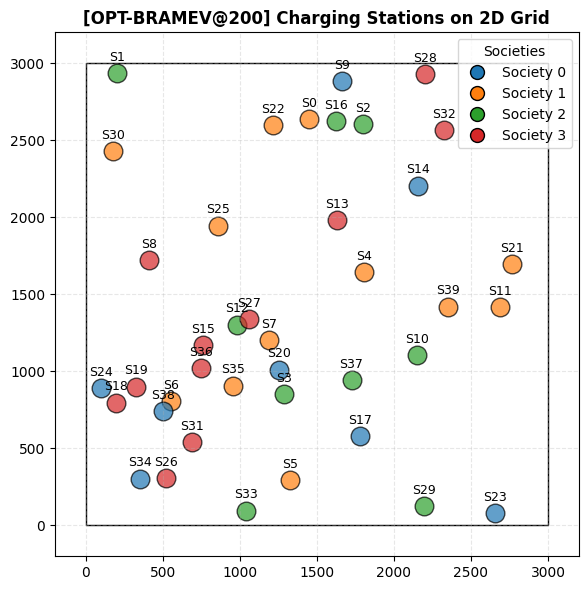

In [114]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

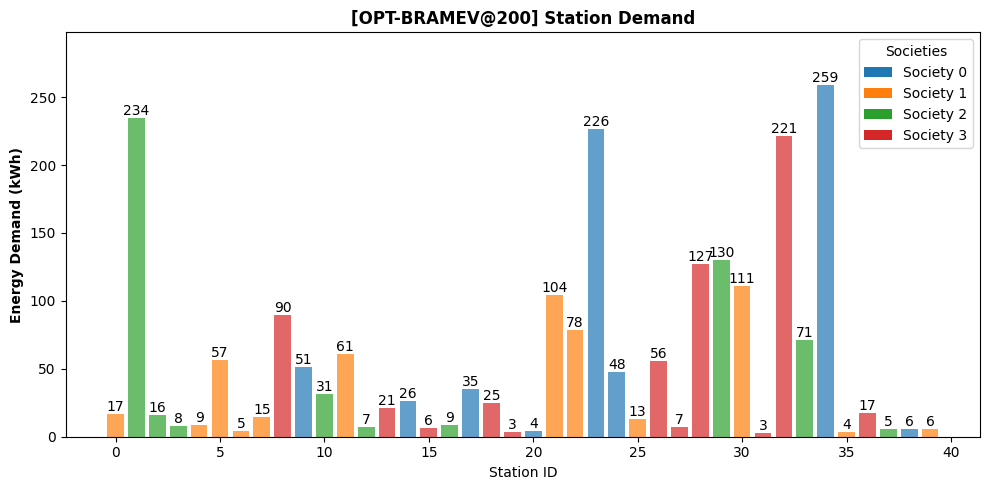

In [115]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

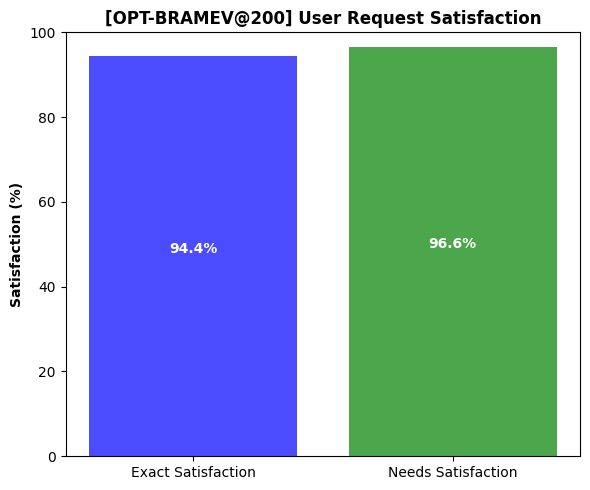

In [116]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

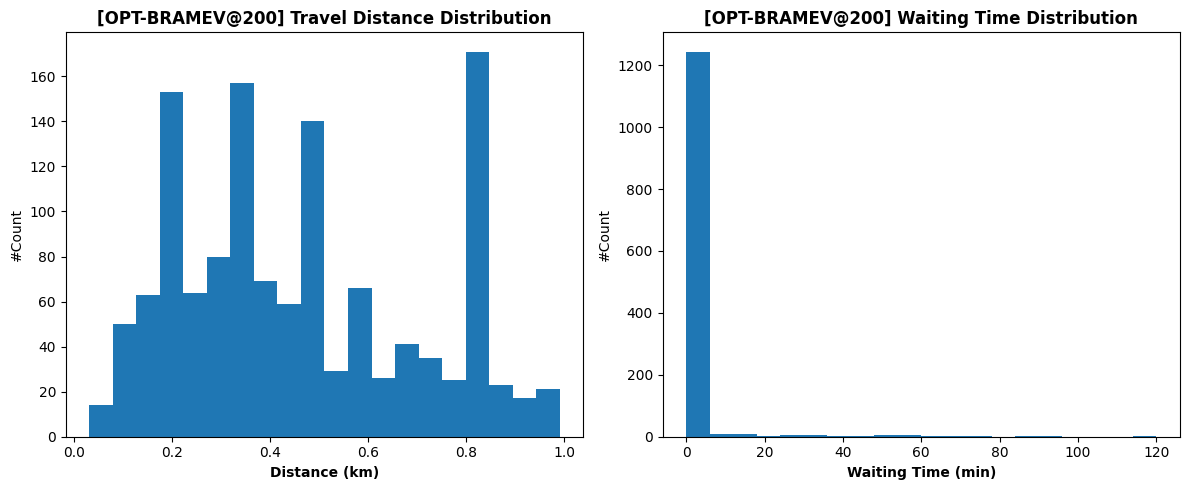

In [117]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

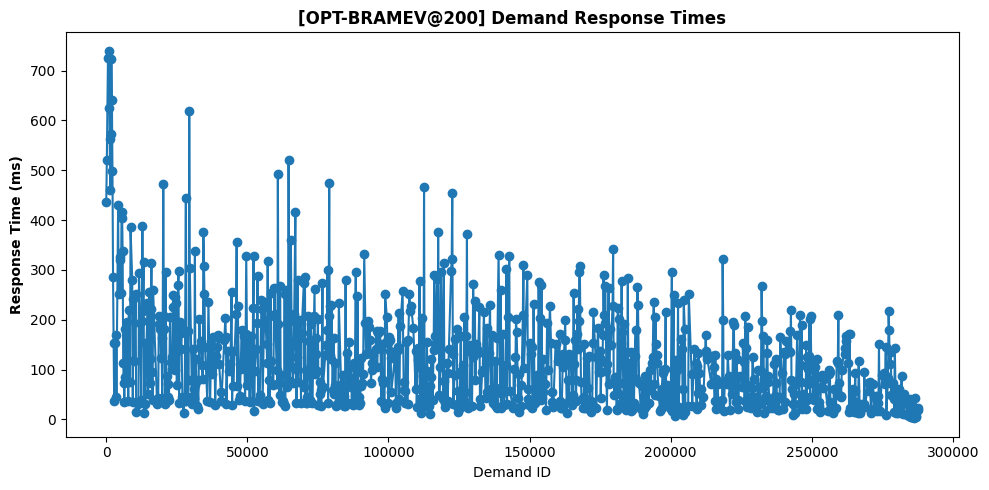

In [118]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

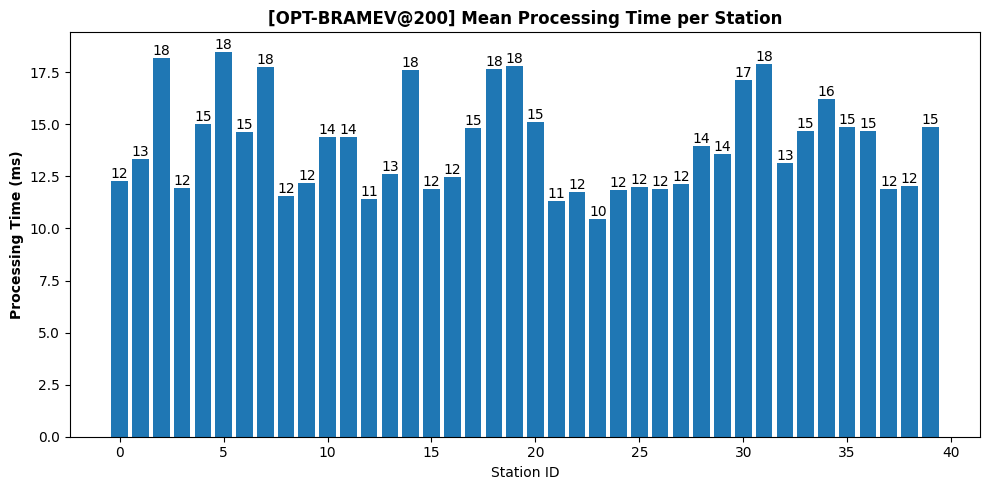

In [119]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

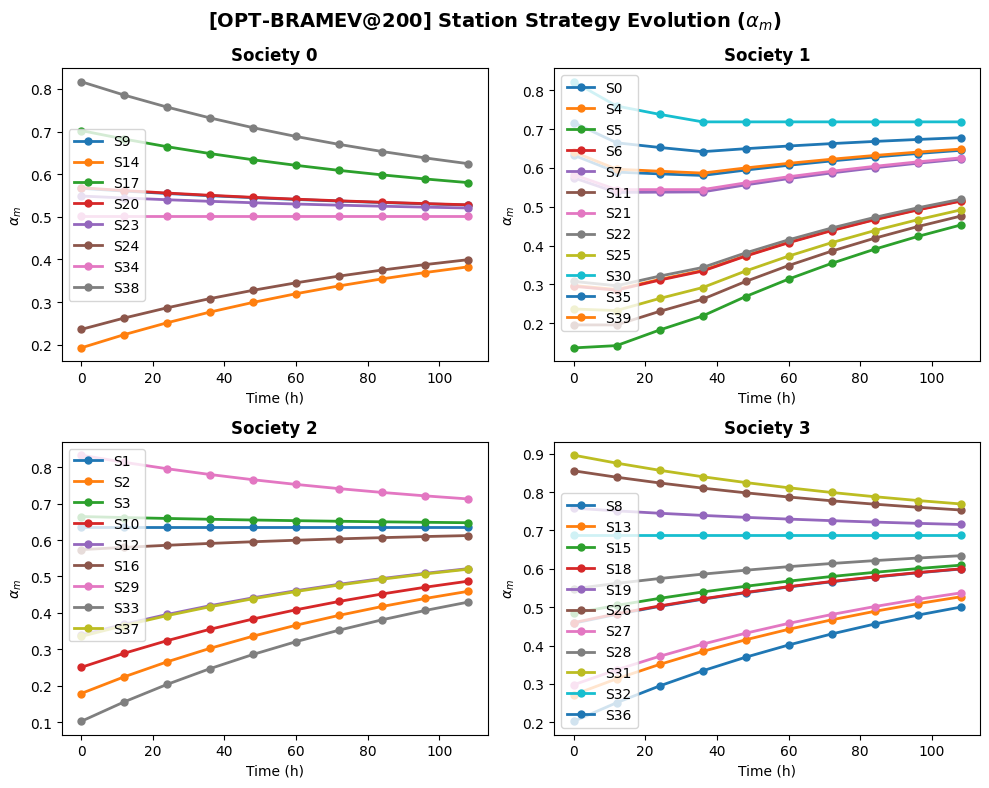

In [120]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [121]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

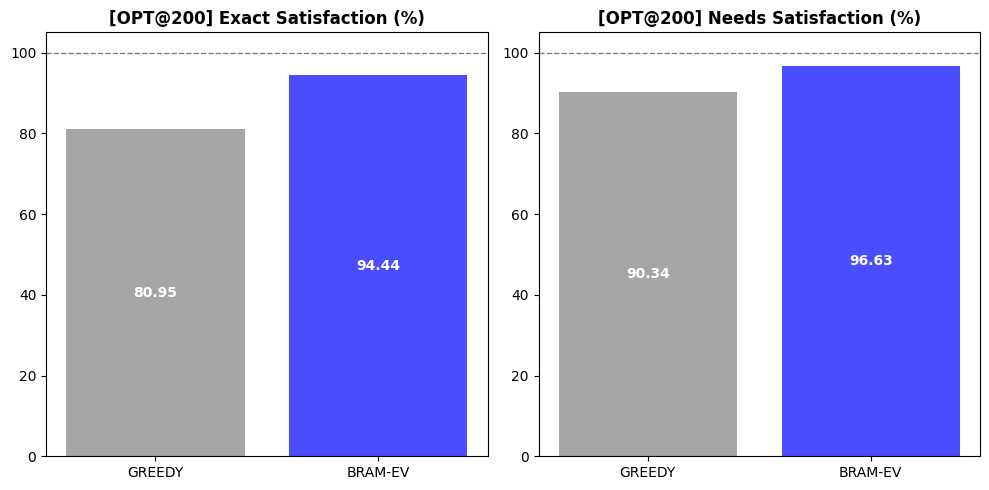

In [122]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

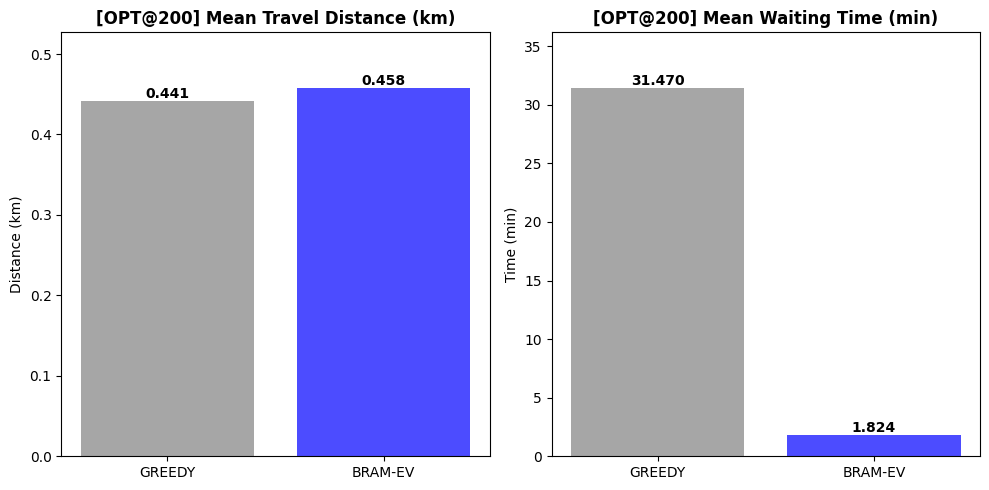

In [123]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

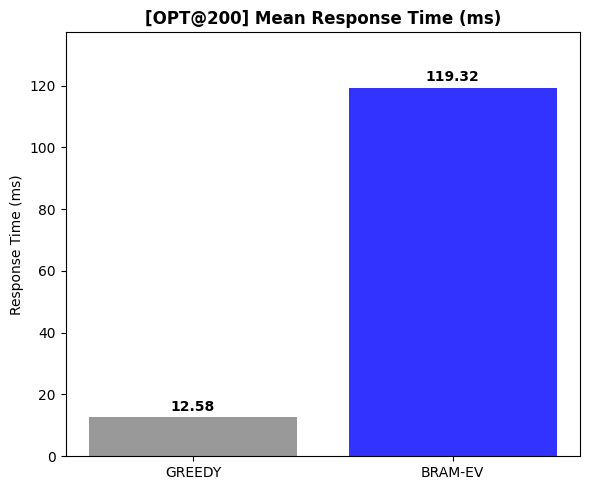

In [124]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [125]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [126]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/250cars


##### *Initialisation*

In [127]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [128]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:33:59.538 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-30 16:33:59.887 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-30 16:34:00.106 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-30 16:34:00.386 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-30 16:34:00.753 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-30 16:34:01.254 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-30 16:34:01.618 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-30 16:34:01.974 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-30 16:34:02.384 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-30 16:34:02.656 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-30 16:34:02.956 | IN

##### *Metrics*

In [129]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 24.77 kWh
  Station 1: 22.02 kWh
  Station 2: 74.37 kWh
  Station 3: 118.00 kWh
  Station 4: 167.58 kWh
  Station 5: 15.18 kWh
  Station 6: 42.66 kWh
  Station 7: 16.59 kWh
  Station 8: 4.37 kWh
  Station 9: 14.62 kWh
  Station 10: 2.27 kWh
  Station 11: 78.01 kWh
  Station 12: 159.40 kWh
  Station 13: 4.96 kWh
  Station 14: 5.03 kWh
  Station 15: 6.89 kWh
  Station 16: 2.47 kWh
  Station 17: 82.78 kWh
  Station 18: 167.48 kWh
  Station 19: 43.27 kWh
  Station 20: 32.12 kWh
  Station 21: 235.18 kWh
  Station 22: 10.76 kWh
  Station 23: 2.07 kWh
  Station 24: 68.27 kWh
  Station 25: 10.62 kWh
  Station 26: 3.60 kWh
  Station 27: 285.60 kWh
  Station 28: 185.97 kWh
  Station 29: 9.24 kWh
  Station 30: 276.01 kWh
  Station 31: 63.17 kWh
  Station 32: 11.71 kWh
  Station 33: 5.41 kWh
  Station 34: 11.13 kWh
  Station 35: 11.97 kWh
  Station 36: 3.23 kWh
  Station 37: 31.26 kWh
  Station 38: 16.12 kWh
  Station 39: 

In [130]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

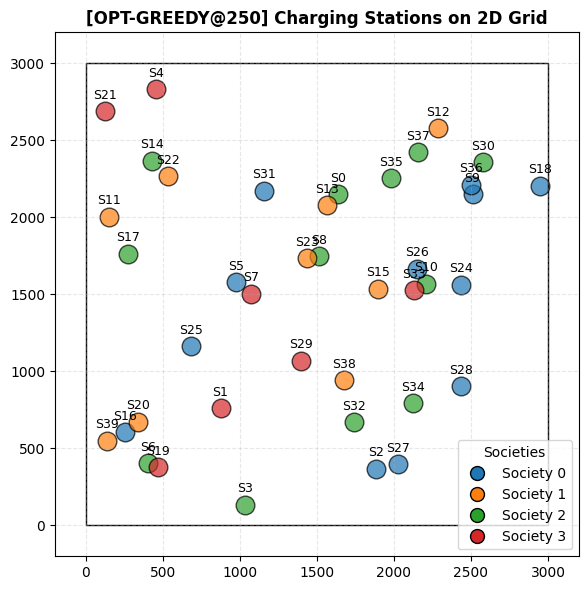

In [131]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

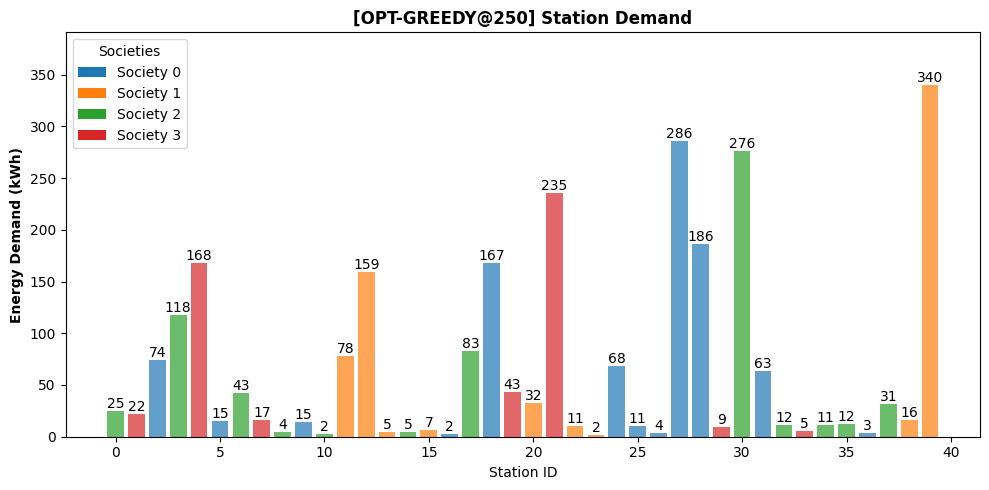

In [132]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

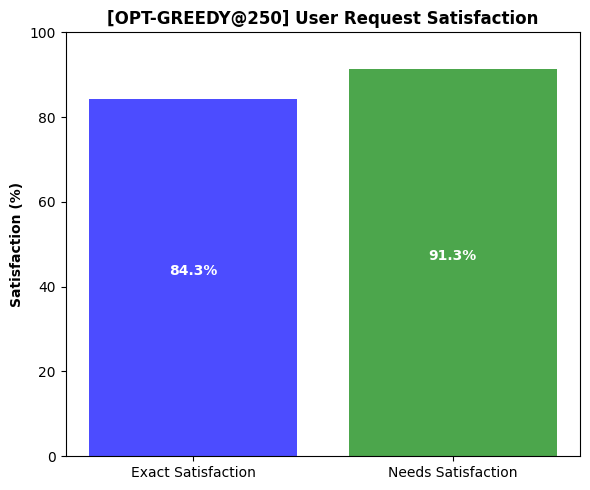

In [133]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

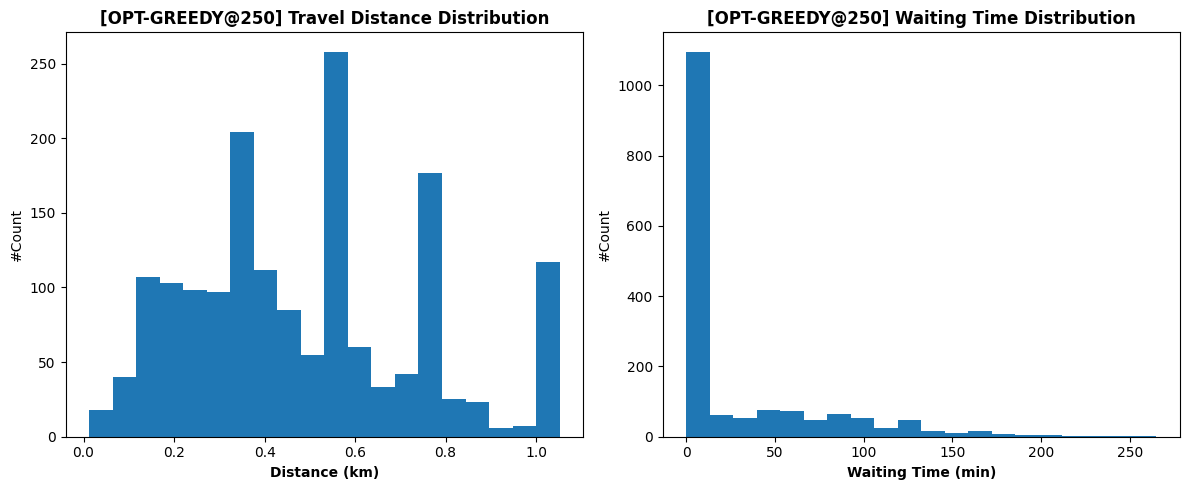

In [134]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

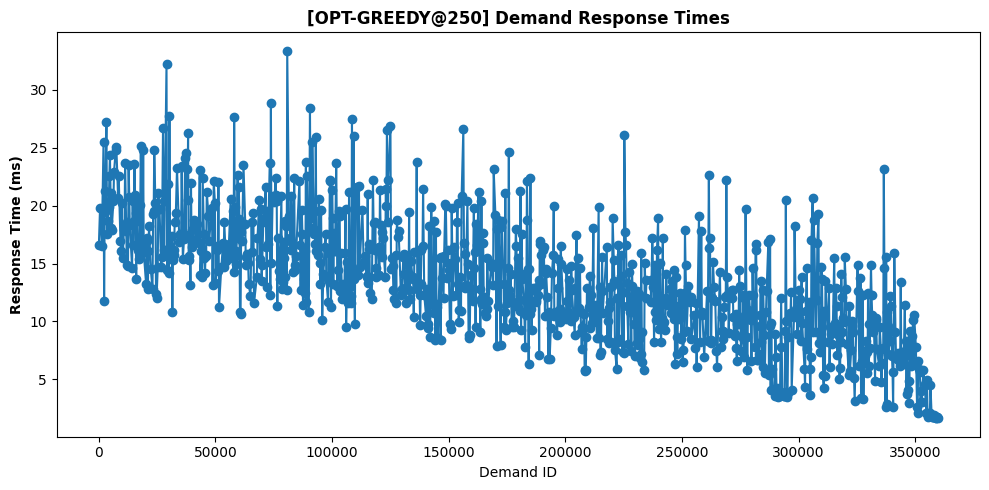

In [135]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

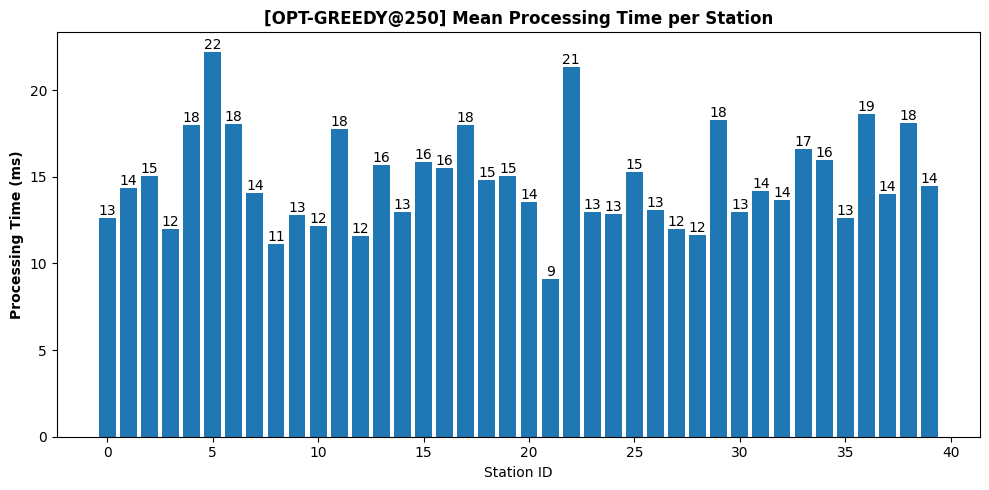

In [136]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [137]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/250cars


##### *Initialisation*

In [138]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [139]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-30 16:34:32.097 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-30 16:34:34.914 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-30 16:34:37.007 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-30 16:34:38.532 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-30 16:34:40.397 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-30 16:34:43.152 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-30 16:34:45.532 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-30 16:34:46.934 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-30 16:34:48.936 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-30 16:34:51.768 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-30 16:34:53.651 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [140]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 29.66 kWh
  Station 1: 13.87 kWh
  Station 2: 68.60 kWh
  Station 3: 188.96 kWh
  Station 4: 98.47 kWh
  Station 5: 43.79 kWh
  Station 6: 5.42 kWh
  Station 7: 210.75 kWh
  Station 8: 18.67 kWh
  Station 9: 144.14 kWh
  Station 10: 128.87 kWh
  Station 11: 77.45 kWh
  Station 12: 111.90 kWh
  Station 13: 36.06 kWh
  Station 14: 9.87 kWh
  Station 15: 19.92 kWh
  Station 16: 132.18 kWh
  Station 17: 5.08 kWh
  Station 18: 7.69 kWh
  Station 19: 14.03 kWh
  Station 20: 106.04 kWh
  Station 21: 49.62 kWh
  Station 22: 60.29 kWh
  Station 23: 34.23 kWh
  Station 24: 205.74 kWh
  Station 25: 62.07 kWh
  Station 26: 3.70 kWh
  Station 27: 50.06 kWh
  Station 28: 20.13 kWh
  Station 29: 36.60 kWh
  Station 30: 222.43 kWh
  Station 31: 28.88 kWh
  Station 32: 19.19 kWh
  Station 33: 15.74 kWh
  Station 34: 8.68 kWh
  Station 35: 92.55 kWh
  Station 36: 229.71 kWh
  Station 37: 121.96 kWh
  Station 38: 20.50 kWh
  Stat

In [141]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

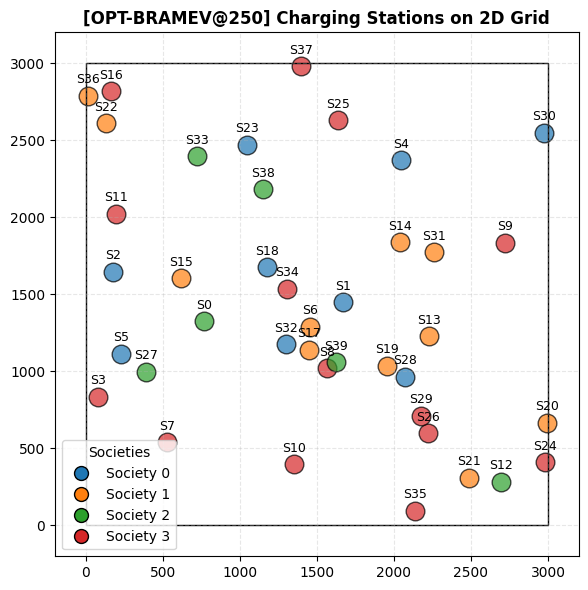

In [142]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

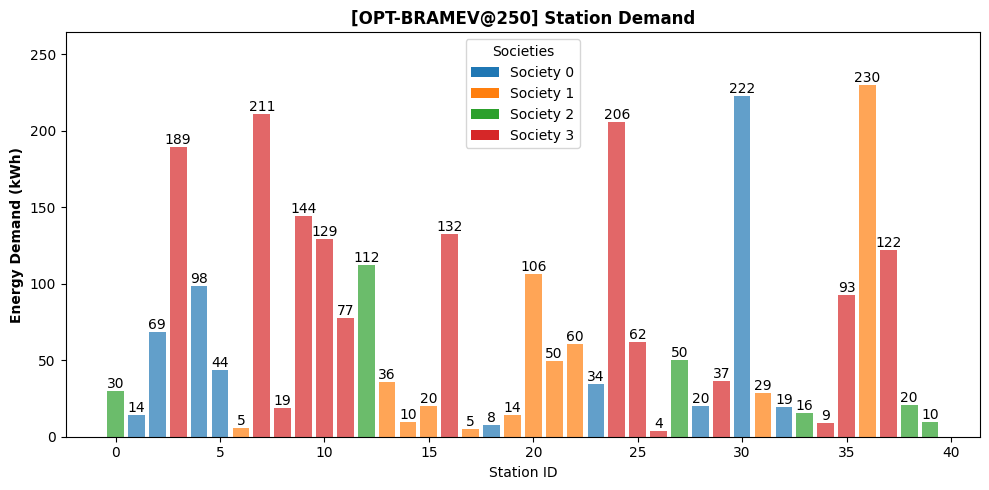

In [143]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

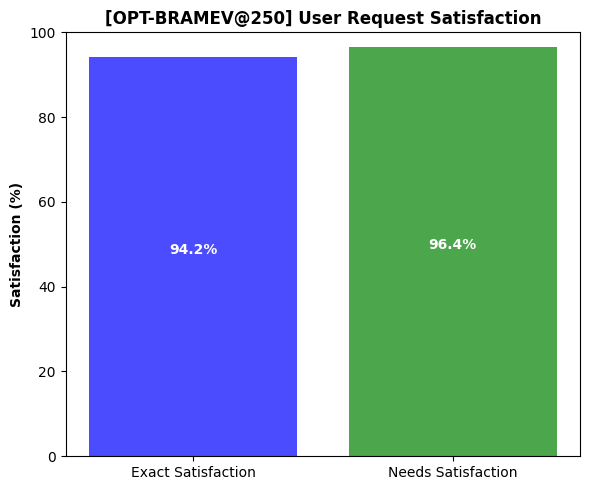

In [144]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

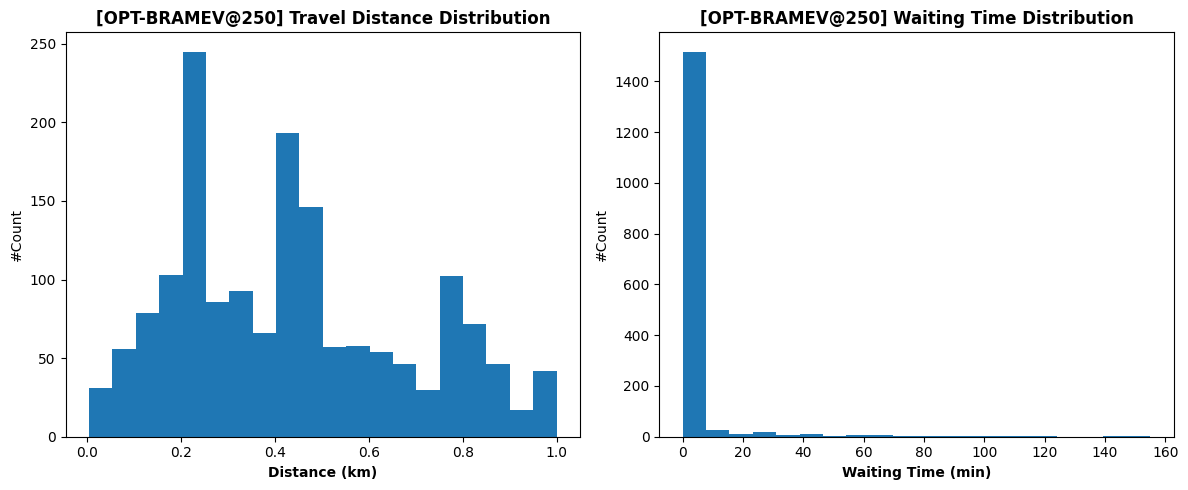

In [145]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

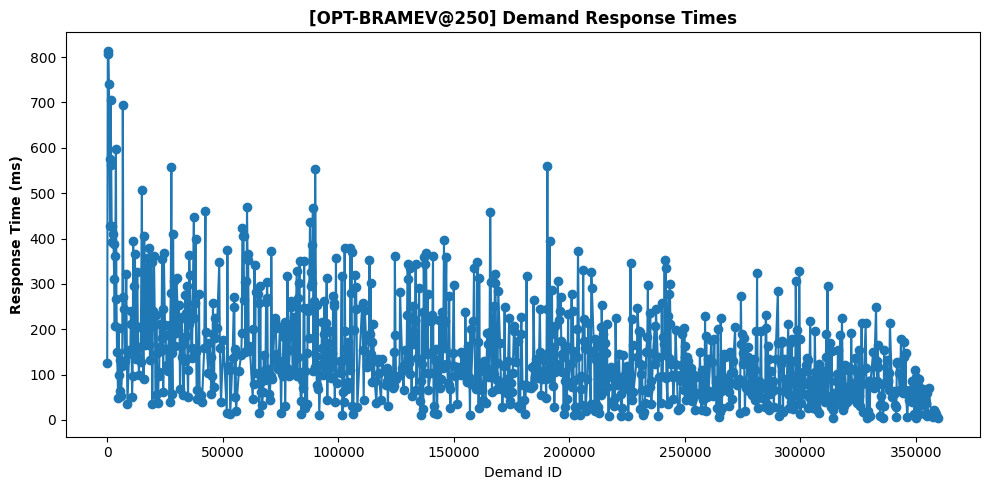

In [146]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

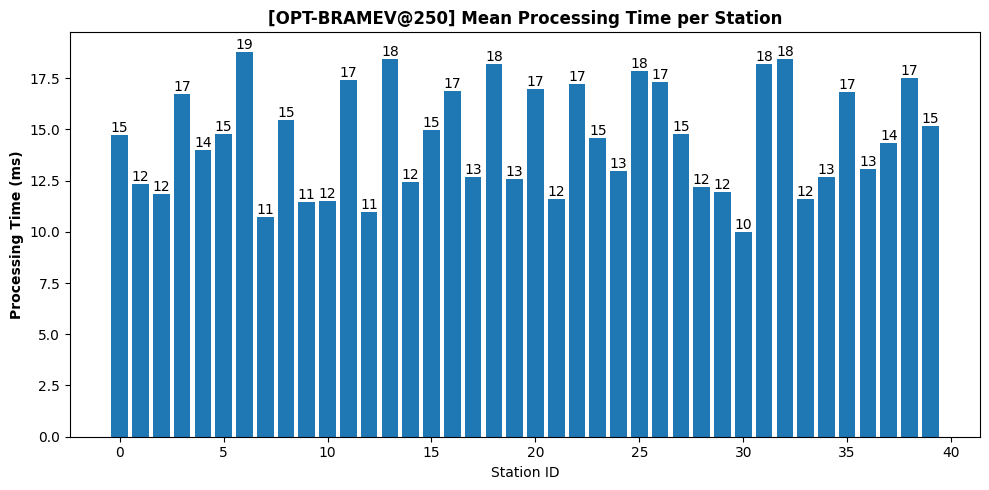

In [147]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

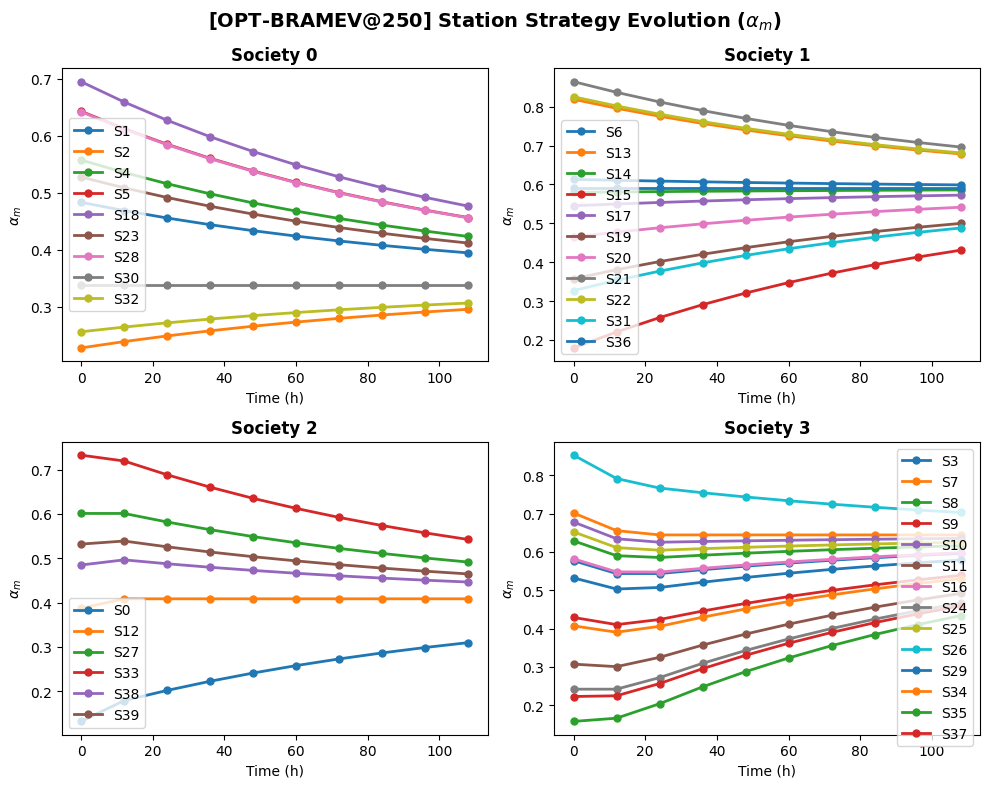

In [148]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [149]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

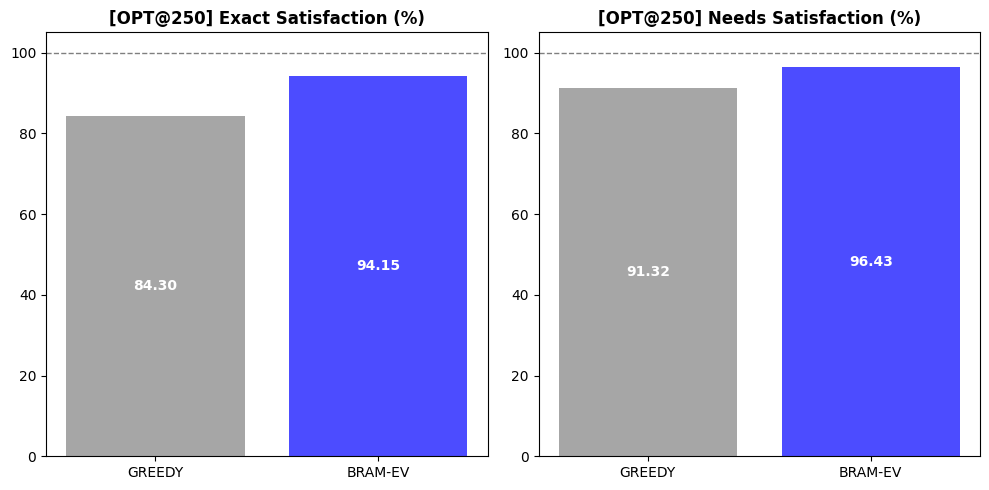

In [150]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

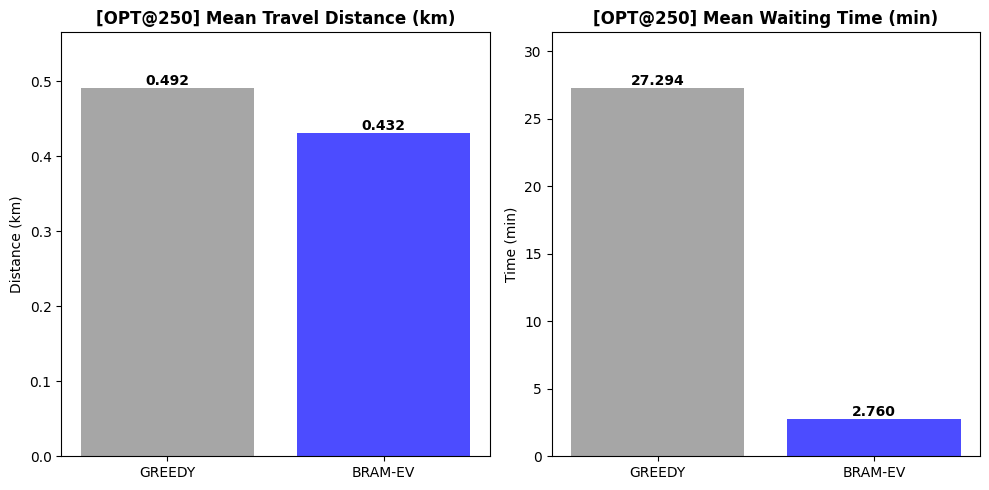

In [151]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

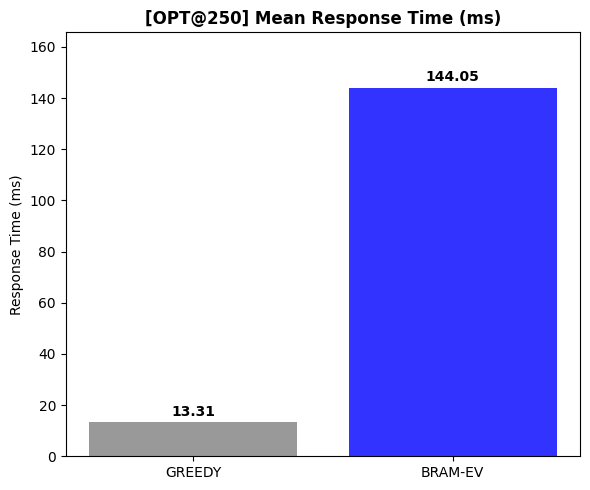

In [152]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

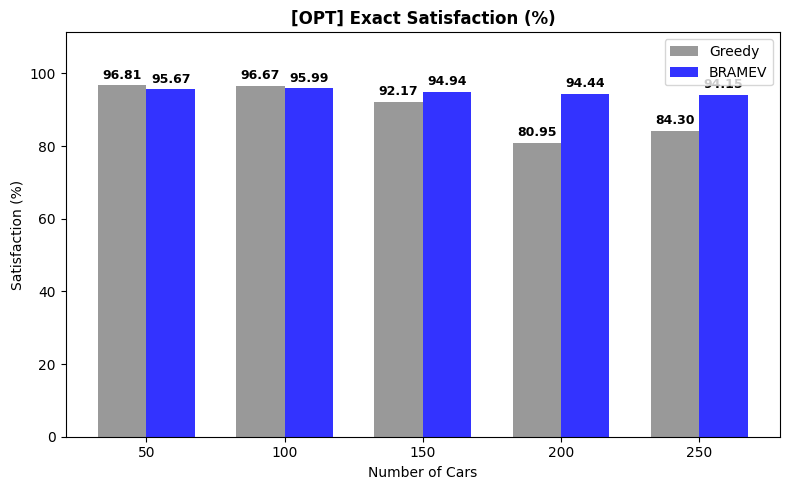

In [153]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

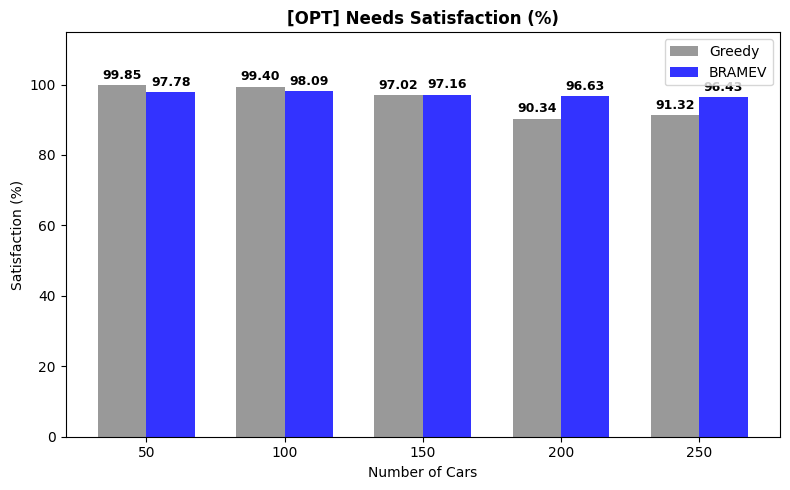

In [154]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

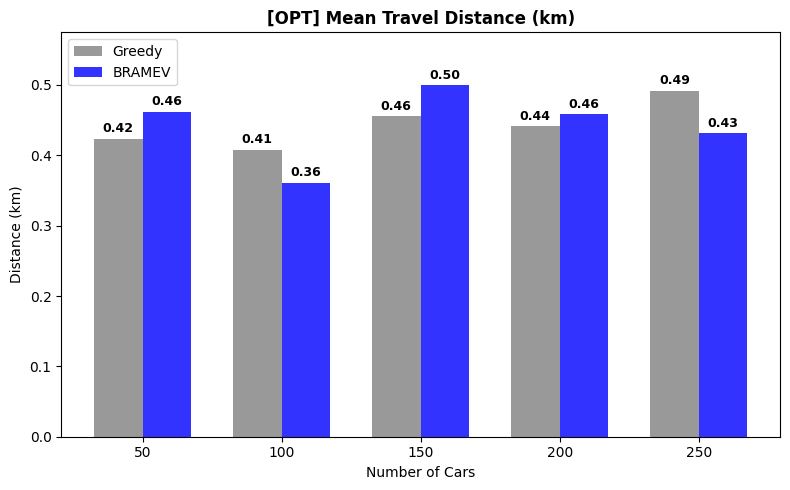

In [155]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


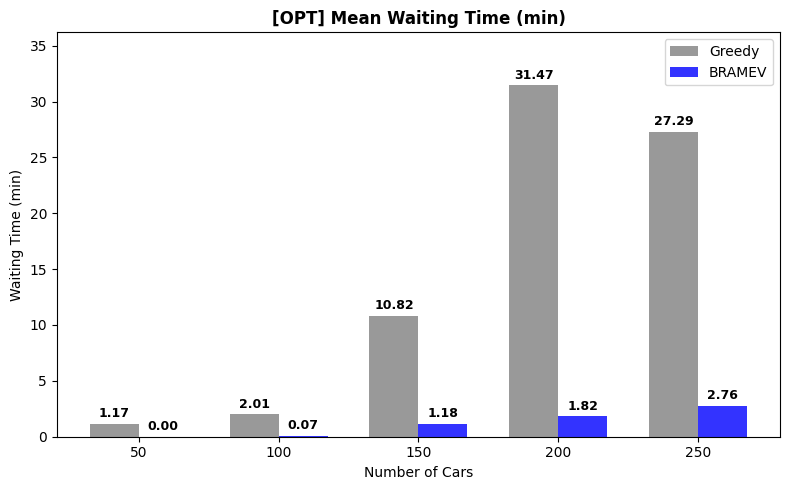

In [156]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


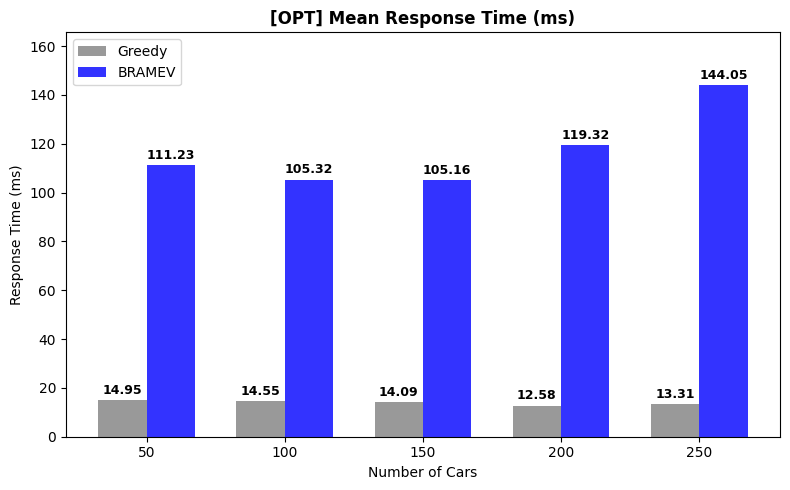

In [157]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
